# Toy PHM: anomaly score, health indicator, prognostics

Twenty minutes on the workshop telemetry (`data/synthetic/synthetic_rrd_metrics.csv`,
5 ports, 30 days, 5-minute cadence). 全部在 notebook 裡執行完，不接 Grafana。

1. **Detection.** Is this sample far from the port's healthy operating point?
2. **Health.** Collapse that distance into one bounded number per asset.
3. **Prognostics.** When does the trajectory reach a limit, and is this asset even in a
   regime where that question has an answer?

Question 3 is where PHM demonstrations usually cheat. This one screens the data for a
degradation regime before estimating anything, and at the month scale finds none.

## 0. Problem and data

Five switch and firewall ports are polled every five minutes for a month, one SNMP-style
counter read per poll, the interface-level telemetry an RRD collector stores. The operational
question is the on-call one: *is this interface behaving the way it normally does, and if not,
how bad and how urgent?* No labels exist at run time, so every model is trained on what normal
looks like and asked to flag departures from it.

The month holds ten injected incidents (A through J) and four planned changes from a change
calendar. Planned changes look identical to incidents in the traffic and must be suppressed
rather than detected, which is why the calendar is a first-class input. The `event_id` /
`event_label` columns are ground truth, used to *score* the models and never to fit them.

Raw columns, all per-interval totals over the 300 s window rather than cumulative counters:

| column | meaning | role here |
| --- | --- | --- |
| `timestamp` | poll time, 5-minute cadence | index |
| `device_id`, `port_id`, `port_role` | which interface, and its function | grouping key |
| `INOCTETS`, `OUTOCTETS` | bytes in / out | throughput |
| `INUCASTPKTS`, `OUTUCASTPKTS` | unicast packets in / out | packet rate |
| `INNUCASTPKTS`, `OUTNUCASTPKTS` | non-unicast packets in / out | packet rate |
| `INBROADCASTPKTS`, `OUTBROADCASTPKTS` | broadcast packets | L2 storm signature |
| `INMULTICASTPKTS`, `OUTMULTICASTPKTS` | multicast packets | flooding signature |
| `INERRORS`, `OUTERRORS` | frame errors | link quality |
| `INDISCARDS`, `OUTDISCARDS` | dropped frames | congestion |
| `INUNKNOWNPROTOS` | frames with an unrecognised protocol | scan / misconfig |
| `event_label`, `event_id` | injected-incident ground truth | scoring only |

Feature construction (section 2), the reference model, and the profile below all read from
this table. The per-port profile and the evaluation split come right after the raw series, once
the frame is built.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from IPython.display import display, HTML

ROOT = pathlib.Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "synthetic"

# Chart chrome: one surface, recessive grid, ink that is never a series colour.
SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e87ba4"]   # validated slot order
STATUS = {"healthy": "#0ca30c", "watch": "#fab219", "degraded": "#ec835a", "critical": "#d03b3b"}
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "grid.color": GRID, "grid.linewidth": 0.7, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 8, "legend.labelcolor": INK2,
    "lines.linewidth": 1.6, "font.size": 9.5,
    # Serif throughout. STIXGeneral is Times-metric and ships with matplotlib, so the
    # mathtext in axis labels ($T^2$, $Q$, $\alpha$) renders in the same face as the prose.
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Charter", "DejaVu Serif"],
    "mathtext.fontset": "stix",
})

# Markdown, tables and figure captions in the same family. Applies in Jupyter and Lab;
# some VS Code notebook builds sanitise injected style, in which case only the figures
# pick up the serif face.
display(HTML("""<style>
.jp-RenderedHTMLCommon, .jp-RenderedMarkdown, .rendered_html,
.jp-RenderedHTMLCommon table, .dataframe, .cell-output-ipywidget-background,
.markdown-body, .output_html {
  font-family: "STIX Two Text", STIXGeneral, "Times New Roman", Charter, Georgia, serif;
}
.jp-RenderedHTMLCommon code, .markdown-body code { font-family: ui-monospace, Menlo, monospace; }
</style>"""))
print("project root:", ROOT)

project root: /path/to/aiops-anomaly-zero-to-hero


## 1. Unit contract

The columns hold the total accumulated *within* each interval, not a monotonic counter.
Differencing them would clip roughly half the samples to zero. The check is empirical:
a real counter has non-negative steps almost everywhere, an interval total near half.

In [2]:
CAD_S = 300.0                                # asserted below against the timestamps
RAW_OCTETS = ["INOCTETS", "OUTOCTETS"]
RAW_PKTS = ["INUCASTPKTS", "OUTUCASTPKTS", "INNUCASTPKTS", "OUTNUCASTPKTS"]
RAW_BCAST = ["INBROADCASTPKTS", "OUTBROADCASTPKTS"]
RAW_MCAST = ["INMULTICASTPKTS", "OUTMULTICASTPKTS"]

raw = pd.read_csv(DATA / "synthetic_rrd_metrics.csv", parse_dates=["timestamp"])
raw = raw.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

cadence = raw.groupby("port_id")["timestamp"].diff().dt.total_seconds().median()
steps = raw.groupby("port_id")["INOCTETS"].diff().dropna()
mono = float((steps >= 0).mean())
semantics = "counter" if mono > 0.97 else "interval-total"
assert cadence == CAD_S, f"cadence changed: {cadence}"
assert semantics == "interval-total", "loader below assumes interval totals"

pd.Series({"rows": f"{len(raw):,}", "ports": raw.port_id.nunique(),
           "span": f"{raw.timestamp.min():%Y-%m-%d} to {raw.timestamp.max():%Y-%m-%d}",
           "cadence_s": f"{cadence:.0f}", "samples_per_day": f"{86400 / cadence:.0f}",
           "monotonic_step_fraction": f"{mono:.3f}", "reading": semantics},
          name="contract").to_frame()

,contract
rows,"43,200"
ports,5
span,2026-02-01 to 2026-03-02
cadence_s,300
samples_per_day,288
monotonic_step_fraction,0.503
reading,interval-total


In [3]:
def build_features(raw, cad_s):
    """Per-second rates plus the ratio features that expose specific fault modes."""
    r = lambda cols: sum(raw[c] for c in cols) / cad_s
    eps = 1e-9
    rx, tx = raw.INOCTETS / cad_s, raw.OUTOCTETS / cad_s
    ucast, bcast, mcast = r(RAW_PKTS), r(RAW_BCAST), r(RAW_MCAST)
    frames = ucast + bcast + mcast
    F = pd.DataFrame({
        "timestamp": raw.timestamp, "device_id": raw.device_id,
        "port_id": raw.port_id, "port_role": raw.port_role,
        "event_label": raw.event_label, "event_id": raw.event_id.fillna(""),
        # load
        "traffic_bps": rx + tx,
        "packets_pps": ucast,
        "tx_ratio": tx / (rx + tx + eps),
        "avg_pkt_bytes": (rx + tx) / (frames + eps),
        # composition
        "broadcast_ratio": bcast / (frames + eps),
        "multicast_ratio": mcast / (frames + eps),
        # quality
        "errors_pps": r(["INERRORS", "OUTERRORS"]),
        "discards_pps": r(["INDISCARDS", "OUTDISCARDS"]),
        "unknown_proto_pps": raw.INUNKNOWNPROTOS / cad_s,
    })
    # Operating regime: traffic is strongly diurnal and weekday/weekend split.
    # Every baseline below is conditioned on the regime, never on the raw clock.
    F["regime"] = np.where(F.timestamp.dt.dayofweek >= 5, "wknd", "week") + "-" + \
                  F.timestamp.dt.hour.astype(str).str.zfill(2)
    return F


F = build_features(raw, CAD_S)

# Ground truth, and the planned-change calendar the detector should stay quiet inside.
cal = pd.read_csv(DATA / "change_calendar.csv", parse_dates=["start_time", "end_time"])
in_change = pd.Series(False, index=F.index)
for c in cal.itertuples():
    scoped = (F.port_id == c.scope) | (F.device_id == c.scope) | (c.scope == "ALL")
    in_change |= scoped & F.timestamp.between(c.start_time, c.end_time)

F["is_event"] = F.event_label != "normal"
F["in_change"] = in_change
F["healthy_ref"] = ~F.is_event & ~F.in_change       # a sample no model should be surprised by

# Temporal hold-out. Reference statistics (regime medians, covariance, control limits,
# severity references) are fitted on TRAIN healthy samples only; VAL tunes the single alarm
# threshold; TEST is scored once. A chronological cut, never a random shuffle: these series
# are autocorrelated and a shuffle would leak future samples into the fit.
VAL_START, TEST_START = pd.Timestamp("2026-02-13"), pd.Timestamp("2026-02-22")
F["split"] = np.select([F.timestamp < VAL_START, F.timestamp < TEST_START],
                        ["train", "val"], "test")
FIT_REF = F.healthy_ref & (F.split == "train")      # the only rows any model is fitted on

TRUTH = (F[F.is_event].groupby(["event_id", "port_id"], as_index=False)
         .agg(event_type=("event_label", "first"), start=("timestamp", "min"),
              end=("timestamp", "max"), n=("timestamp", "size")).sort_values("start"))
TRUTH["split"] = np.select([TRUTH.start < VAL_START, TRUTH.start < TEST_START],
                           ["train", "val"], "test")
SPAN_DAYS = (F.timestamp.max() - F.timestamp.min()).total_seconds() / 86400

TRUTH.assign(duration_min=lambda d: (d.end - d.start).dt.total_seconds() / 60)

,event_id,port_id,event_type,start,end,n,split,duration_min
0,A,port-id7430,business_traffic_growth,2026-02-04 09:00:00,2026-02-04 10:55:00,24,train,115.0
1,B,port-id7428,small_packet_scan,2026-02-06 13:10:00,2026-02-06 13:55:00,10,train,45.0
2,C,port-id7431,large_file_backup,2026-02-08 01:00:00,2026-02-08 03:55:00,36,train,175.0
3,D,port-id7427,queue_congestion,2026-02-11 15:20:00,2026-02-11 16:25:00,14,train,65.0
4,E,port-id7429,link_quality_issue,2026-02-14 10:35:00,2026-02-14 11:10:00,8,val,35.0
5,F,port-id7427,load_sensitive_link_issue,2026-02-17 16:00:00,2026-02-17 17:25:00,18,val,85.0
10,G,port-id7431,broadcast_storm,2026-02-19 11:30:00,2026-02-19 12:25:00,12,val,55.0
9,G,port-id7430,broadcast_storm,2026-02-19 11:30:00,2026-02-19 12:25:00,12,val,55.0
8,G,port-id7429,broadcast_storm,2026-02-19 11:30:00,2026-02-19 12:25:00,12,val,55.0
7,G,port-id7428,broadcast_storm,2026-02-19 11:30:00,2026-02-19 12:25:00,12,val,55.0


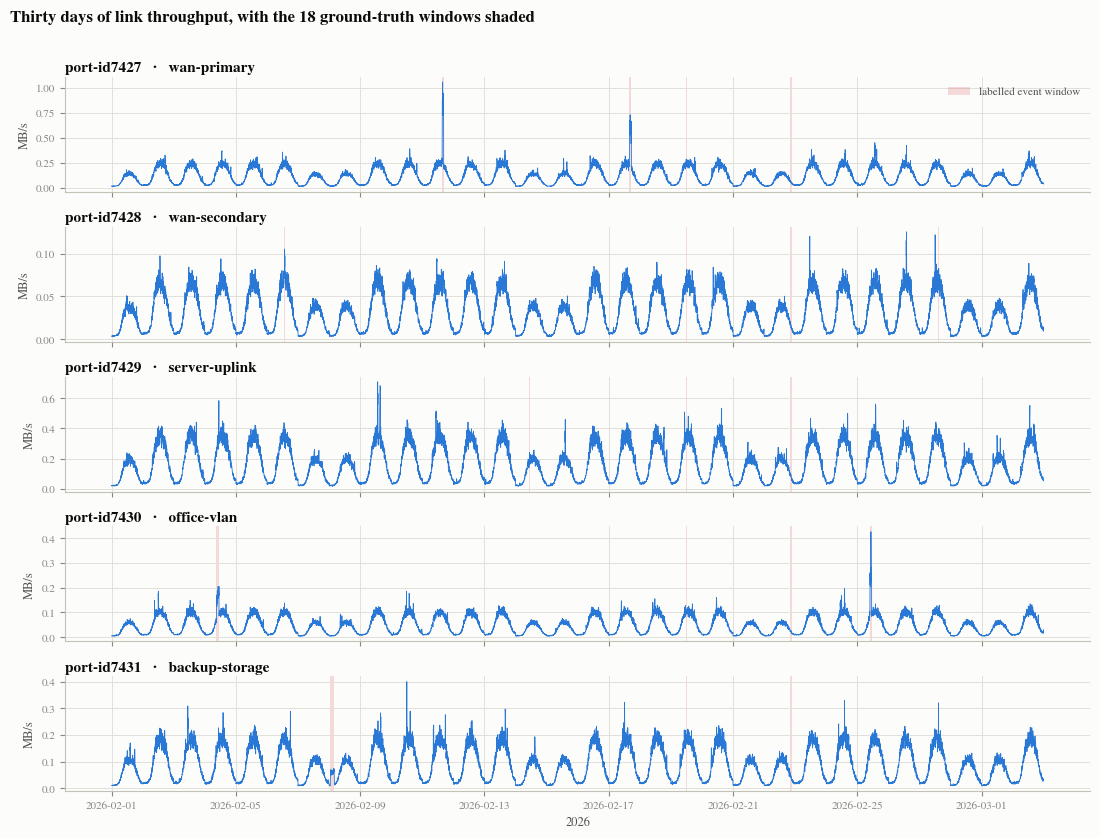

In [4]:
PORTS = sorted(F.port_id.unique())
ROLE = F.groupby("port_id").port_role.first()
DEMO_PORT = "port-id7427"          # wan-primary: carries events D, F, G and H

def shade_events(ax, port, color="#d03b3b", alpha=0.18):
    """Shade ground-truth windows without letting off-screen ones widen the axis."""
    lo, hi = ax.get_xlim()
    for t in TRUTH[TRUTH.port_id == port].itertuples():
        ax.axvspan(t.start, t.end, color=color, alpha=alpha, lw=0, zorder=0)
    ax.set_xlim(lo, hi)

# Small multiples: one series per facet, so identity rides on the facet title
# and no categorical hue has to carry five-way separation.
fig, axes = plt.subplots(len(PORTS), 1, figsize=(11, 8.5), sharex=True)
for ax, port in zip(axes, PORTS):
    g = F[F.port_id == port]
    ax.plot(g.timestamp, g.traffic_bps / 1e6, color=SERIES[0], lw=0.6)
    shade_events(ax, port)
    ax.set_ylabel("MB/s")
    ax.set_title(f"{port}   ·   {ROLE[port]}", loc="left", pad=4)
axes[0].legend(handles=[Patch(facecolor="#d03b3b", alpha=0.18, label="labelled event window")],
               loc="upper right")
axes[-1].set_xlabel("2026")
fig.suptitle("Thirty days of link throughput, with the 18 ground-truth windows shaded",
             x=0.005, ha="left", size=12, weight="600", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

### Per-port profile, and the evaluation split

Throughput runs a strong daily cycle and a 5x scale gap between ports, so a baseline has to be
conditioned on operating regime and fitted per port. The quality channels sit at exactly zero
almost always and spike during faults, so they carry no usable statistical scale and take an
engineering limit instead (section 3). The month is cut chronologically: reference statistics
fit on TRAIN, the alarm threshold tunes on VAL, TEST is scored once.

In [5]:
profile = (F.groupby(["port_id", "port_role"], observed=True)
           .agg(samples=("timestamp", "size"),
                traffic_MBps_median=("traffic_bps", lambda s: s.median() / 1e6),
                traffic_MBps_p95=("traffic_bps", lambda s: s.quantile(0.95) / 1e6),
                error_frac_nonzero=("errors_pps", lambda s: (s > 0).mean()),
                incidents=("event_id", lambda s: s[s != ""].nunique()))
           .reset_index())
profile.style.hide(axis="index").format({
    "traffic_MBps_median": "{:.2f}", "traffic_MBps_p95": "{:.2f}",
    "error_frac_nonzero": "{:.1%}"}).set_caption("per-port profile over the full month")

port_id,port_role,samples,traffic_MBps_median,traffic_MBps_p95,error_frac_nonzero,incidents
port-id7427,wan-primary,8640,0.10,0.25,2.6%,4
port-id7428,wan-secondary,8640,0.03,0.07,2.3%,4
port-id7429,server-uplink,8640,0.15,0.36,2.5%,3
port-id7430,office-vlan,8640,0.04,0.11,2.5%,4
port-id7431,backup-storage,8640,0.08,0.19,2.4%,3


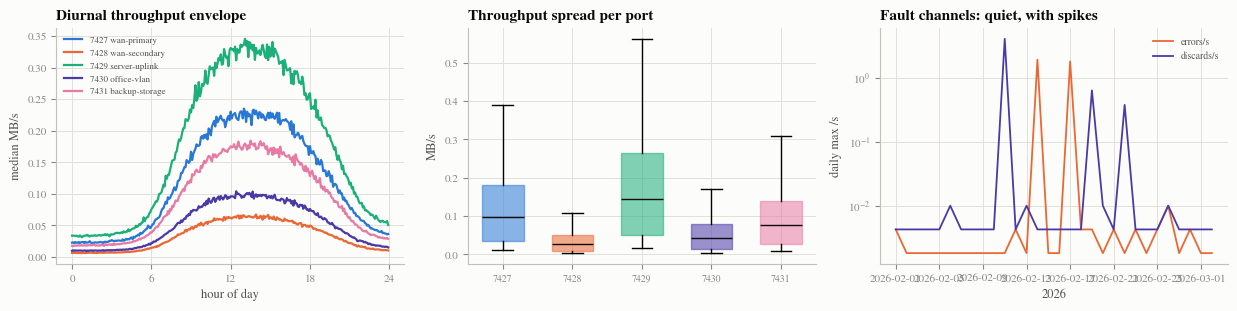

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
roles = F.drop_duplicates("port_id").set_index("port_id").port_role
day = F.assign(hour=F.timestamp.dt.hour + F.timestamp.dt.minute / 60)
for i, port in enumerate(PORTS):
    prof = day[day.port_id == port].groupby("hour").traffic_bps.median() / 1e6
    axes[0].plot(prof.index, prof.values, color=SERIES[i], lw=1.6,
                 label=f"{port.replace('port-id', '')} {roles[port]}")
axes[0].set_xlabel("hour of day"); axes[0].set_ylabel("median MB/s")
axes[0].set_xticks(range(0, 25, 6)); axes[0].legend(fontsize=6.5, loc="upper left")
axes[0].set_title("Diurnal throughput envelope", loc="left")

box = [F.loc[F.port_id == p, "traffic_bps"].to_numpy() / 1e6 for p in PORTS]
bp = axes[1].boxplot(box, widths=0.6, showfliers=False, patch_artist=True,
                     medianprops=dict(color=INK))
for patch, c in zip(bp["boxes"], SERIES):
    patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor(c)
axes[1].set_xticks(range(1, 6), [p.replace("port-id", "") for p in PORTS], fontsize=7)
axes[1].set_ylabel("MB/s"); axes[1].set_title("Throughput spread per port", loc="left")

qual = F.groupby(F.timestamp.dt.floor("D")).agg(
    errors=("errors_pps", "max"), discards=("discards_pps", "max")).reset_index()
axes[2].plot(qual.timestamp, qual.errors, color=SERIES[1], lw=1.3, label="errors/s")
axes[2].plot(qual.timestamp, qual.discards, color=SERIES[3], lw=1.3, label="discards/s")
axes[2].set_yscale("symlog", linthresh=0.01); axes[2].set_ylabel("daily max /s")
axes[2].set_xlabel("2026"); axes[2].legend(fontsize=7)
axes[2].set_title("Fault channels: quiet, with spikes", loc="left")
fig.tight_layout()
plt.show()

In [7]:
split_view = (TRUTH.groupby("split").agg(
    truth_windows=("event_id", "size"),
    incidents=("event_id", lambda s: ", ".join(sorted(s.unique())))).reindex(["train", "val", "test"]))
split_view.insert(0, "days", F.groupby("split").timestamp.agg(
    lambda s: (s.max() - s.min()).days + 1).reindex(["train", "val", "test"]))
split_view.style.set_caption("chronological hold-out (fit on train, tune on val, score on test)")

,days,truth_windows,incidents
split,,,
train,12,4,"A, B, C, D"
val,9,7,"E, F, G"
test,9,7,"H, I, J"


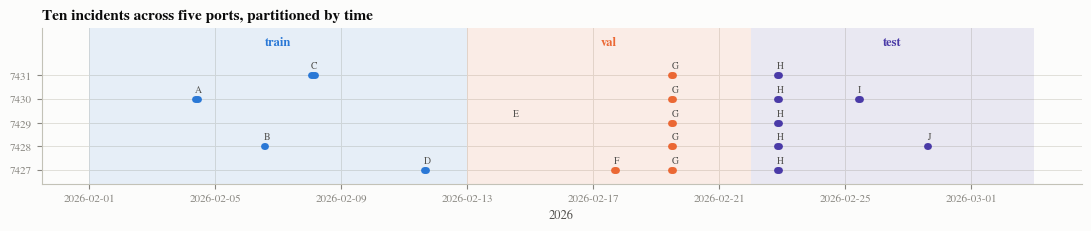

In [8]:
fig, ax = plt.subplots(figsize=(11, 2.4))
SPLIT_C = {"train": SERIES[0], "val": SERIES[1], "test": SERIES[3]}
for name, lo, hi in [("train", F.timestamp.min(), VAL_START),
                     ("val", VAL_START, TEST_START), ("test", TEST_START, F.timestamp.max())]:
    ax.axvspan(lo, hi, color=SPLIT_C[name], alpha=0.10, lw=0)
    ax.text(lo + (hi - lo) / 2, 5.4, name, ha="center", va="center", color=SPLIT_C[name],
            weight="600", fontsize=9)
for t in TRUTH.itertuples():
    y = PORTS.index(t.port_id)
    ax.plot([t.start, t.end], [y, y], color=SPLIT_C[t.split], lw=5, solid_capstyle="round")
    ax.annotate(t.event_id, xy=(t.start, y + 0.28), fontsize=7, color=INK2)
ax.set_yticks(range(len(PORTS)), [p.replace("port-id", "") for p in PORTS], fontsize=8)
ax.set_ylim(-0.6, 6); ax.set_xlabel("2026")
ax.set_title("Ten incidents across five ports, partitioned by time", loc="left")
fig.tight_layout()
plt.show()

## 2. Two kinds of feature

Nine features come out of section 1, in three groups by the fault mode each is built to expose:

| group | feature | formula | reads as |
| --- | --- | --- | --- |
| load | `traffic_bps` | `(INOCTETS + OUTOCTETS) / cadence` | total throughput, in + out |
| load | `packets_pps` | unicast packets/s, in + out | packet rate |
| load | `tx_ratio` | `OUT / (IN + OUT)` bytes | directionality: 0.5 symmetric, near 1 upload-heavy |
| load | `avg_pkt_bytes` | bytes/s ÷ frames/s | mean packet size: small = scan-like, large = bulk transfer |
| composition | `broadcast_ratio` | broadcast frames ÷ total frames | L2 storm / loop signature |
| composition | `multicast_ratio` | multicast frames ÷ total frames | multicast flooding signature |
| quality | `errors_pps` | `(INERRORS + OUTERRORS) / cadence` | physical link errors |
| quality | `discards_pps` | `(INDISCARDS + OUTDISCARDS) / cadence` | congestion / queue overflow |
| quality | `unknown_proto_pps` | `INUNKNOWNPROTOS / cadence` | misconfig or protocol scan |

A z-score needs a scale, and not every feature has one. The table below profiles all nine on
healthy samples only:

| column | meaning |
| --- | --- |
| `median` | typical healthy value, in the feature's own units |
| `zero_scale_regimes` | share of port × hour × weekday/weekend buckets where the MAD is exactly 0 |
| `zero_valued_samples` | share of healthy samples where the feature reads exactly 0 |
| `kind` | `statistical` gets a regime z-score; `boundary` gets a fixed limit instead |
| `limit` | the boundary features' fixed cutoff (blank for statistical features) |

Load and composition features have spread everywhere. The quality features have none anywhere:
errors sit at exactly zero in 97.5% of healthy samples, so the MAD is zero in 100% of regimes
and the division is undefined. Those three get an engineering limit instead, matching the
`errors_pps > 0.05` alert rule the workshop stack already ships.

In [9]:
STAT_FEATS = ["traffic_bps", "packets_pps", "tx_ratio", "avg_pkt_bytes",
              "broadcast_ratio", "multicast_ratio"]
BOUNDARY_LIMITS = {"errors_pps": 0.05, "discards_pps": 0.05, "unknown_proto_pps": 0.02}
ALL_FEATS = STAT_FEATS + list(BOUNDARY_LIMITS)

mad = lambda s: float(np.median(np.abs(s - np.median(s))) * 1.4826)

ref = F[F.healthy_ref]
diag = pd.DataFrame({
    "median": ref.groupby("port_id")[ALL_FEATS].median().median(),
    "zero_scale_regimes": [
        float((ref.groupby(["port_id", "regime"])[f].apply(mad) <= 0).mean()) for f in ALL_FEATS],
    "zero_valued_samples": [float((ref[f] == 0).mean()) for f in ALL_FEATS],
})
diag["kind"] = np.where(diag.index.isin(STAT_FEATS), "statistical", "boundary")
diag["limit"] = pd.Series(BOUNDARY_LIMITS)
diag.style.format({"median": "{:,.4f}", "zero_scale_regimes": "{:.0%}",
                   "zero_valued_samples": "{:.1%}", "limit": "{:.2f}"}, na_rep="")

,median,zero_scale_regimes,zero_valued_samples,kind,limit
traffic_bps,"77,148.2586",0%,0.0%,statistical,
packets_pps,66.5700,0%,0.0%,statistical,
tx_ratio,0.4504,0%,0.0%,statistical,
avg_pkt_bytes,879.2605,0%,0.0%,statistical,
broadcast_ratio,0.0030,0%,0.0%,statistical,
multicast_ratio,0.0048,0%,0.0%,statistical,
errors_pps,0.0000,100%,97.6%,boundary,0.05
discards_pps,0.0000,100%,91.6%,boundary,0.05
unknown_proto_pps,0.0000,100%,99.0%,boundary,0.02


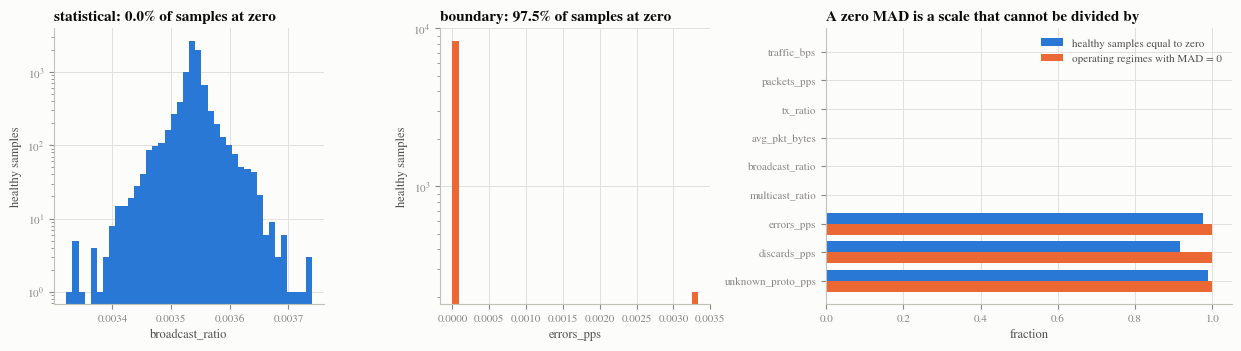

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6),
                         gridspec_kw={"width_ratios": [1, 1, 1.5]})

# One feature of each kind, at the same healthy port, drawn the same way.
for ax, (feat, colour, kind) in zip(axes, [("broadcast_ratio", SERIES[0], "statistical"),
                                           ("errors_pps", SERIES[1], "boundary")]):
    v = ref.loc[ref.port_id == DEMO_PORT, feat].to_numpy()
    ax.hist(v, bins=40, color=colour)
    ax.set_yscale("log")
    ax.set_xlabel(feat); ax.set_ylabel("healthy samples")
    ax.set_title(f"{kind}: {(v == 0).mean():.1%} of samples at zero", loc="left")

# And the two facts that force the split, for every feature.
a2 = axes[2]
pos = np.arange(len(ALL_FEATS)); w = 0.38
a2.barh(pos - w / 2, diag.zero_valued_samples, w, color=SERIES[0],
        label="healthy samples equal to zero")
a2.barh(pos + w / 2, diag.zero_scale_regimes, w, color=SERIES[1],
        label="operating regimes with MAD = 0")
a2.set_yticks(pos, ALL_FEATS, fontsize=8)
a2.set_xlim(0, 1.05)
a2.set_xlabel("fraction")
a2.legend(loc="upper right")   # the six statistical rows are empty, so the box sits on nothing
a2.set_title("A zero MAD is a scale that cannot be divided by", loc="left")
a2.invert_yaxis()
fig.tight_layout()
plt.show()

## 3. Regime normalisation

Each statistical feature is centered on its regime median and divided by its regime MAD.
Two guards. A relative floor at 5% of the regime median stops the quantised composition
ratios, counted in whole packets per five minutes, from turning measurement resolution
into a z-score of several hundred. A cap at ±25 marks a reading as beyond measurable
range so one saturated feature cannot dominate a covariance.

In [11]:
Z_CAP = 25.0
REL_FLOOR = 0.05

def robust_z(F, feats, ref_mask):    # ref_mask = FIT_REF, so no val/test row informs a centre
    ref = F[ref_mask]
    key = pd.MultiIndex.from_arrays([F.port_id, F.regime])
    out = {}
    for f in feats:
        grp = ref.groupby(["port_id", "regime"])[f]
        centre = grp.median().reindex(key).to_numpy()
        scale = grp.apply(mad).reindex(key).to_numpy()
        floor = (REL_FLOOR * grp.median().abs()).reindex(key).to_numpy()
        scale = np.maximum(scale, np.maximum(floor, 1e-12))
        out["z_" + f] = np.clip((F[f].to_numpy() - centre) / scale, -Z_CAP, Z_CAP)
    return pd.DataFrame(out, index=F.index)


Z = robust_z(F, STAT_FEATS, FIT_REF)          # regime centre and scale from TRAIN only
ZC = list(Z.columns)
pd.DataFrame({
    "healthy_std": Z[F.healthy_ref].std(),          # ~1 unless the floor is binding
    "at_cap_healthy": (Z[F.healthy_ref].abs() >= Z_CAP).mean(),
    "at_cap_event": (Z[F.is_event].abs() >= Z_CAP).mean(),
}).style.format({"healthy_std": "{:.3f}", "at_cap_healthy": "{:.4%}", "at_cap_event": "{:.2%}"})

,healthy_std,at_cap_healthy,at_cap_event
z_traffic_bps,1.194,0.0000%,18.18%
z_packets_pps,1.169,0.0000%,4.20%
z_tx_ratio,1.020,0.0000%,0.00%
z_avg_pkt_bytes,1.039,0.0000%,6.99%
z_broadcast_ratio,0.329,0.0000%,20.98%
z_multicast_ratio,0.285,0.0000%,31.47%


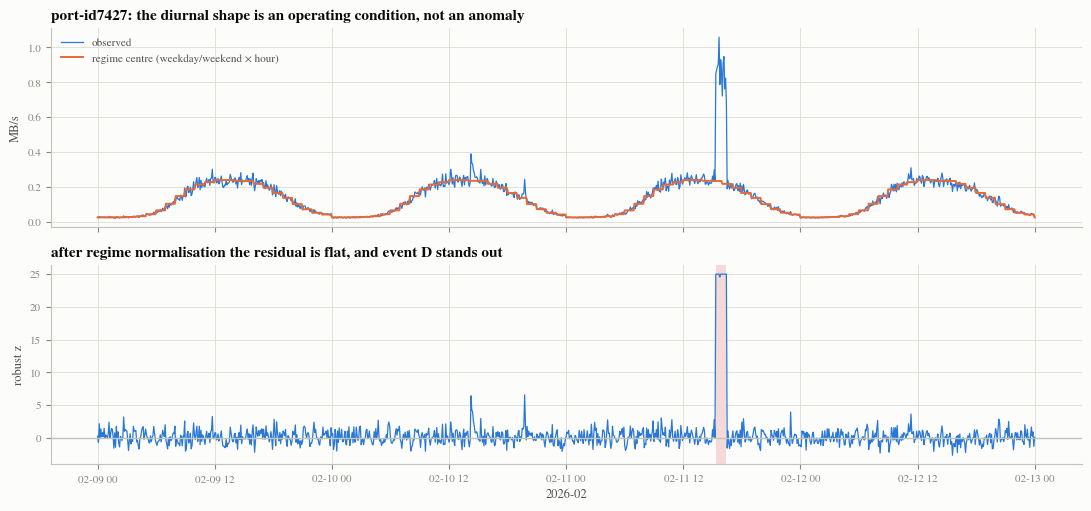

In [12]:
g = F[(F.port_id == DEMO_PORT) & F.timestamp.between("2026-02-09", "2026-02-13")]
zg = Z.loc[g.index]

fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True)
a0.plot(g.timestamp, g.traffic_bps / 1e6, color=SERIES[0], lw=0.9, label="observed")
prof = ref.groupby(["port_id", "regime"]).traffic_bps.median()
a0.plot(g.timestamp, prof.reindex(pd.MultiIndex.from_arrays([g.port_id, g.regime])).to_numpy() / 1e6,
        color=SERIES[1], lw=1.4, label="regime centre (weekday/weekend × hour)")
a0.set_ylabel("MB/s"); a0.legend(loc="upper left")
a0.set_title(f"{DEMO_PORT}: the diurnal shape is an operating condition, not an anomaly",
             loc="left")

a1.plot(g.timestamp, zg.z_traffic_bps, color=SERIES[0], lw=0.9)
a1.axhline(0, color="#c3c2b7", lw=1)
shade_events(a1, DEMO_PORT)
a1.set_ylabel("robust z"); a1.set_xlabel("2026-02")
a1.set_title("after regime normalisation the residual is flat, and event D stands out", loc="left")
fig.tight_layout()
plt.show()

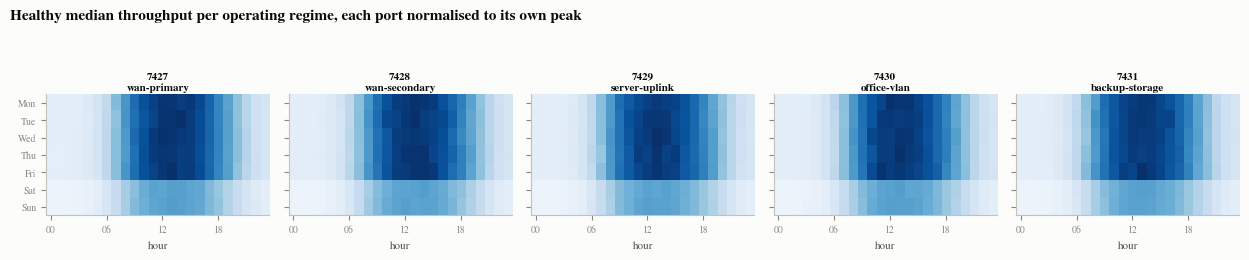

,peak_hour,peak_over_trough,weekend_over_weekday
port_id,,,
port-id7427,13,10.0x,0.60x
port-id7428,13,10.0x,0.61x
port-id7429,13,9.9x,0.57x
port-id7430,13,9.7x,0.59x
port-id7431,13,9.9x,0.60x


In [13]:
# The regime grid itself. Every cell is a separate baseline, fitted on healthy samples only.
prof2d = (F[F.healthy_ref]
          .assign(dow=F.timestamp.dt.dayofweek, hour=F.timestamp.dt.hour)
          .groupby(["port_id", "dow", "hour"]).traffic_bps.median())

fig, axes = plt.subplots(1, len(PORTS), figsize=(12.5, 2.6), sharey=True)
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for ax, port in zip(axes, PORTS):
    grid = prof2d.loc[port].unstack("hour")
    grid = grid / grid.to_numpy().max()                 # each port on its own scale
    ax.imshow(grid.to_numpy(), aspect="auto", cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks(range(0, 24, 6), [f"{h:02d}" for h in range(0, 24, 6)], fontsize=7)
    ax.set_yticks(range(7), DAYS, fontsize=7)
    ax.grid(False)
    ax.set_title(f"{port.replace('port-id', '')}\n{ROLE[port]}", fontsize=8, pad=3)
    ax.set_xlabel("hour", fontsize=8)
fig.suptitle("Healthy median throughput per operating regime, each port normalised to its own peak",
             x=0.005, ha="left", size=11, weight="600", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

shape = prof2d.groupby(["port_id", "hour"]).mean().unstack("hour")
wk = F[F.healthy_ref].assign(wknd=F.timestamp.dt.dayofweek >= 5)
summary = pd.DataFrame({
    "peak_hour": shape.idxmax(axis=1),
    "peak_over_trough": shape.max(axis=1) / shape.min(axis=1),
    "weekend_over_weekday": (wk[wk.wknd].groupby("port_id").traffic_bps.median()
                             / wk[~wk.wknd].groupby("port_id").traffic_bps.median()),
})
summary.style.format({"peak_over_trough": "{:.1f}x", "weekend_over_weekday": "{:.2f}x"})

## 4. Multivariate distance: Mahalanobis, then the PCA split

Per-feature residuals miss faults that keep every feature inside its own range while breaking
the relationship between them. Mahalanobis distance $d = \sqrt{(z-\mu)^\top S^{-1} (z-\mu)}$
uses the healthy covariance $S$, so a sample is far when it is far *relative to how the
features normally move together*.

Principal component analysis splits that same distance in two. Hotelling's $T^2$ measures
displacement inside the subspace the healthy data occupies. The squared prediction error
$Q = \lVert z - \hat{z}\rVert^2$ measures displacement out of it.

Read the per-event result rather than the aggregate. Across all events the median $T^2$
sits at its own alarm limit while $Q$ sits at fifteen times its own, since most of these
faults break the correlation between features instead of sliding along it. Two invert
that: F moves $T^2$ to 3.8 and leaves $Q$ at 0.5, and E moves neither, because E rides
entirely on the quality features section 2 excluded from this space.

In [14]:
def fit_health_space(z, healthy, evr_target=0.90):
    """Healthy-only location, covariance and principal subspace for one port."""
    r = z[healthy]
    mu = np.median(r, axis=0)
    S = np.cov(r - mu, rowvar=False)
    w, V = np.linalg.eigh(S)
    order = np.argsort(w)[::-1]
    w, V = w[order], V[:, order]
    k = int(np.searchsorted(np.cumsum(w) / w.sum(), evr_target) + 1)
    return {"mu": mu, "S_inv": np.linalg.pinv(S), "P": V[:, :k], "lam": w[:k],
            "k": k, "evr": np.cumsum(w) / w.sum()}


def score_health_space(z, m):
    d = z - m["mu"]
    t = d @ m["P"]
    return (np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", d, m["S_inv"], d), 0.0)),   # Mahalanobis
            np.sqrt((t ** 2 / m["lam"]).sum(1)),                                     # sqrt T^2
            np.sqrt(((d - t @ m["P"].T) ** 2).sum(1)))                               # sqrt Q (SPE)


MODELS = {}
for col in ("d_maha", "t2", "spe"):
    F[col] = np.nan
for port, idx in F.groupby("port_id").groups.items():
    idx = np.asarray(idx)
    z = Z.loc[idx].to_numpy()
    m = MODELS[port] = fit_health_space(z, FIT_REF.to_numpy()[idx])   # covariance from TRAIN
    F.loc[idx, ["d_maha", "t2", "spe"]] = np.column_stack(score_health_space(z, m))

m = MODELS[DEMO_PORT]
corr = pd.DataFrame(np.corrcoef(Z[F.healthy_ref & (F.port_id == DEMO_PORT)].to_numpy(), rowvar=False),
                    index=ZC, columns=ZC)
display(corr.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:+.2f}")
        .set_caption(f"{DEMO_PORT} healthy residual correlation "
                     f"({m['k']} components hold {m['evr'][m['k'] - 1]:.1%} of variance)"))

sep = pd.DataFrame({
    "healthy_p50": F.loc[F.healthy_ref, ["d_maha", "t2", "spe"]].median(),
    "healthy_p99": F.loc[F.healthy_ref, ["d_maha", "t2", "spe"]].quantile(0.99),
    "healthy_p99.9": F.loc[F.healthy_ref, ["d_maha", "t2", "spe"]].quantile(0.999),
    "event_p50": F.loc[F.is_event, ["d_maha", "t2", "spe"]].median(),
})
sep["separation"] = sep.event_p50 / sep["healthy_p99"]
sep.style.format("{:.2f}").set_caption("distance statistics, healthy versus event")

,z_traffic_bps,z_packets_pps,z_tx_ratio,z_avg_pkt_bytes,z_broadcast_ratio,z_multicast_ratio
z_traffic_bps,+1.00,+0.83,+0.01,-0.01,-0.01,+0.00
z_packets_pps,+0.83,+1.00,+0.02,-0.51,-0.00,+0.01
z_tx_ratio,+0.01,+0.02,+1.00,-0.00,-0.01,+0.01
z_avg_pkt_bytes,-0.01,-0.51,-0.00,+1.00,-0.01,-0.01
z_broadcast_ratio,-0.01,-0.00,-0.01,-0.01,+1.00,-0.03
z_multicast_ratio,+0.00,+0.01,+0.01,-0.01,-0.03,+1.00


,healthy_p50,healthy_p99,healthy_p99.9,event_p50,separation
d_maha,2.02,6.49,10.90,77.59,11.95
t2,1.48,4.04,7.42,3.98,0.99
spe,0.22,1.70,2.63,25.01,14.67


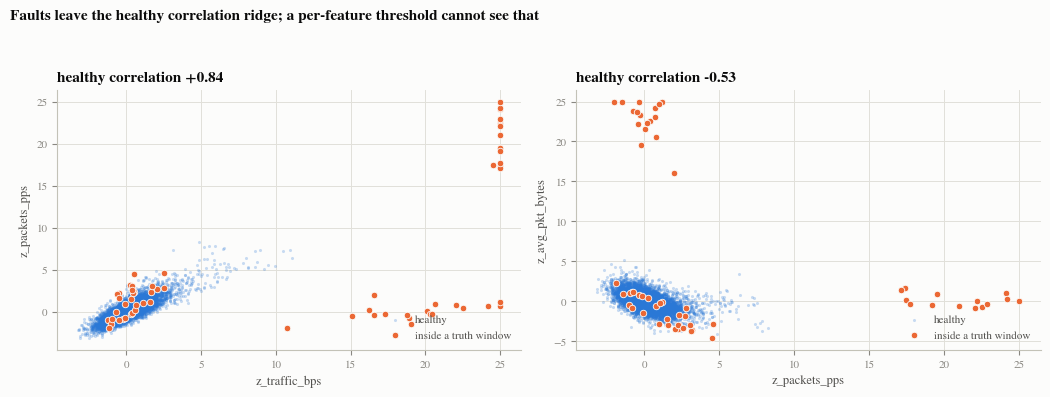

In [15]:
# What a correlation break looks like before any distance is computed.
sel = F.port_id == DEMO_PORT
zz = Z[sel]; hh = F.loc[sel, "healthy_ref"]; ee = F.loc[sel, "is_event"]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
pairs = [("z_traffic_bps", "z_packets_pps", 0.84), ("z_packets_pps", "z_avg_pkt_bytes", -0.53)]
for ax, (xc, yc, rho) in zip(axes, pairs):
    ax.scatter(zz.loc[hh, xc], zz.loc[hh, yc], s=5, color=SERIES[0], alpha=0.25, lw=0,
               label="healthy")
    ax.scatter(zz.loc[ee, xc], zz.loc[ee, yc], s=22, color=SERIES[1], lw=0.6,
               edgecolor=SURFACE, label="inside a truth window", zorder=3)
    ax.set_xlabel(xc); ax.set_ylabel(yc)
    ax.set_title(f"healthy correlation {rho:+.2f}", loc="left")
    ax.legend(loc="lower right")
fig.suptitle("Faults leave the healthy correlation ridge; a per-feature threshold cannot see that",
             x=0.005, ha="left", size=11, weight="600", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

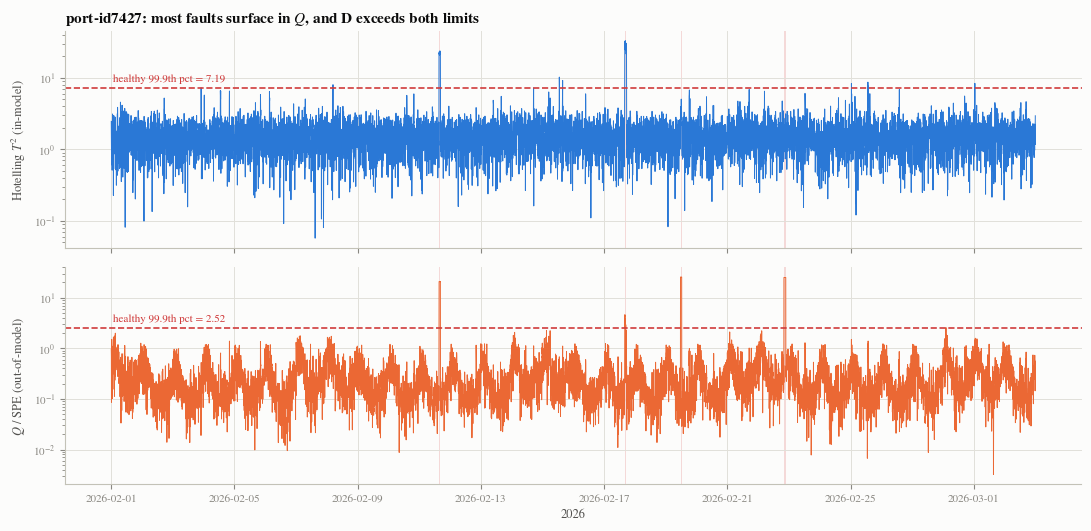

,t2,spe,sensitive_statistic,either_over_limit
event_id,,,,
A,1.13,5.25,Q,True
B,2.39,11.02,Q,True
C,4.35,5.64,Q,True
D,3.10,8.24,Q,True
E,0.31,0.12,T2,False
F,3.99,1.00,T2,True
G,0.44,10.11,Q,True
H,0.23,9.93,Q,True
I,2.56,4.21,Q,True


In [16]:
LIMITS = {c: F.loc[FIT_REF, c].quantile(0.999) for c in ("t2", "spe")}   # control limits from TRAIN
g = F[F.port_id == DEMO_PORT]

fig, axes = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)
for ax, (col, name, colour) in zip(axes, [("t2", "Hotelling $T^2$ (in-model)", SERIES[0]),
                                          ("spe", "$Q$ / SPE (out-of-model)", SERIES[1])]):
    ax.plot(g.timestamp, g[col], color=colour, lw=0.7)
    ax.axhline(LIMITS[col], color=STATUS["critical"], ls="--", lw=1.2)
    ax.annotate(f"healthy 99.9th pct = {LIMITS[col]:.2f}",
                xy=(g.timestamp.iloc[20], LIMITS[col]), xytext=(0, 5),
                textcoords="offset points", color=STATUS["critical"], size=8)
    shade_events(ax, DEMO_PORT)
    ax.set_yscale("log"); ax.set_ylabel(name)
axes[0].set_title(f"{DEMO_PORT}: most faults surface in $Q$, and D exceeds both limits",
                  loc="left")
axes[1].set_xlabel("2026")
fig.tight_layout()
plt.show()

ratio = F.loc[F.is_event].groupby("event_id")[["t2", "spe"]].median().div(pd.Series(LIMITS))
ratio["sensitive_statistic"] = np.where(ratio.spe > ratio.t2, "Q", "T2")
ratio["either_over_limit"] = ratio[["t2", "spe"]].max(axis=1) > 1
ratio.style.format({"t2": "{:.2f}", "spe": "{:.2f}"}).set_caption(
    "median score per event, as a multiple of its own 99.9th-percentile limit")

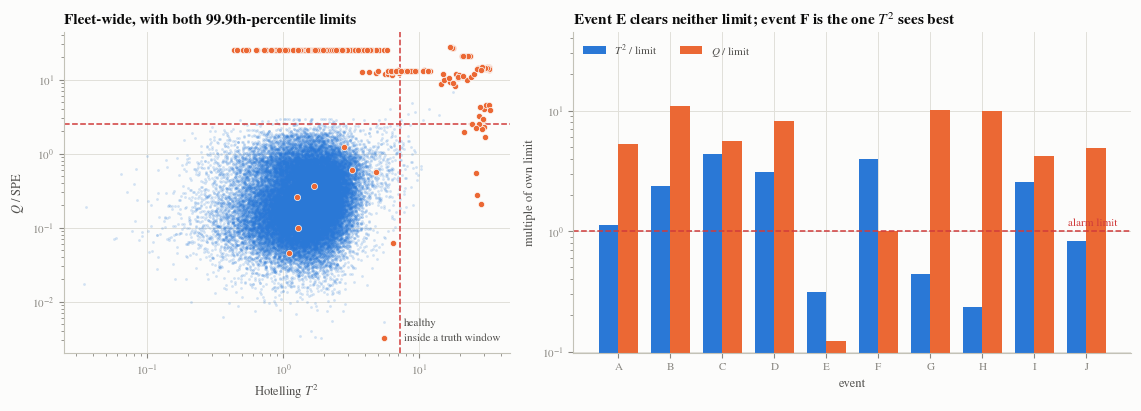

In [17]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11.5, 4.2),
                             gridspec_kw={"width_ratios": [1, 1.25]})

# Quadrant view: the two statistics are independent axes, so plot them as such.
a0.scatter(F.loc[F.healthy_ref, "t2"], F.loc[F.healthy_ref, "spe"], s=4, color=SERIES[0],
           alpha=0.2, lw=0, label="healthy")
a0.scatter(F.loc[F.is_event, "t2"], F.loc[F.is_event, "spe"], s=20, color=SERIES[1], lw=0.5,
           edgecolor=SURFACE, label="inside a truth window", zorder=3)
a0.axvline(LIMITS["t2"], color=STATUS["critical"], ls="--", lw=1.1)
a0.axhline(LIMITS["spe"], color=STATUS["critical"], ls="--", lw=1.1)
a0.set_xscale("log"); a0.set_yscale("log")
a0.set_xlabel("Hotelling $T^2$"); a0.set_ylabel("$Q$ / SPE")
a0.legend(loc="lower right")
a0.set_title("Fleet-wide, with both 99.9th-percentile limits", loc="left")

# Per-event magnitude, as a multiple of each statistic's own limit.
x = np.arange(len(ratio)); w = 0.38
a1.bar(x - w / 2, ratio.t2, w, color=SERIES[0], label="$T^2$ / limit")
a1.bar(x + w / 2, ratio.spe, w, color=SERIES[1], label="$Q$ / limit")
a1.axhline(1.0, color=STATUS["critical"], ls="--", lw=1.1)
a1.annotate("alarm limit", xy=(len(ratio) - 0.4, 1.0), xytext=(0, 4), textcoords="offset points",
            ha="right", color=STATUS["critical"], size=8)
a1.set_yscale("log"); a1.set_ylim(top=45); a1.set_xticks(x, ratio.index)
a1.set_xlabel("event"); a1.set_ylabel("multiple of own limit")
a1.legend(loc="upper left", ncols=2)
a1.set_title("Event E clears neither limit; event F is the one $T^2$ sees best", loc="left")
fig.tight_layout()
plt.show()

## 5. From distance to health indicator

A distance is unbounded and port-specific. A health indicator has to be bounded in
$[0, 1]$, monotone decreasing in severity, comparable across ports, and wide enough in
dynamic range that a fault twice as bad reads as worse instead of saturating.

The mapping is logarithmic in severity,

$$\mathrm{HI} = 1 - \frac{\log_{10}(1 + s)}{\log_{10}(1 + s_{\max})},$$

with $s$ the severity in units of that channel's own reference and $s_{\max} = 100$ the
severity treated as total loss of health. The reference is the healthy 99.5th percentile
for statistical channels and the engineering limit for the boundary channel, which puts
all three on one scale without pooling incomparable quantities.

Three sub-indicators stay separate, then fuse by minimum. Weakest-link is the right
default operationally: a port with clean throughput and a rising error count is in bad
health on one axis, which averaging would hide. The geometric mean is kept alongside and
is the better input to a trend model.

In [18]:
S_MAX = 100.0
GROUPS = {"load": ["z_traffic_bps", "z_packets_pps", "z_tx_ratio", "z_avg_pkt_bytes"],
          "shape": ["z_broadcast_ratio", "z_multicast_ratio"]}
EWMA_HALFLIFE = 3          # 15 minutes at a 5-minute cadence

hi_from_severity = lambda s: np.clip(1 - np.log10(1 + np.maximum(s, 0)) / np.log10(1 + S_MAX), 0, 1)

for name, cols in GROUPS.items():
    sev = Z[cols].abs().max(axis=1)
    s_ref = F[FIT_REF].assign(_s=sev).groupby("port_id")._s.quantile(0.995)
    F[f"hi_{name}"] = hi_from_severity(sev / F.port_id.map(s_ref).to_numpy())
F["hi_quality"] = hi_from_severity(
    np.max([F[c] / lim for c, lim in BOUNDARY_LIMITS.items()], axis=0))

SUB = ["hi_load", "hi_shape", "hi_quality"]
F["hi"] = F[SUB].min(axis=1)                                   # weakest link
F["hi_geo"] = np.exp(np.log(F[SUB].clip(lower=1e-6)).mean(axis=1))
F["hi_s"] = F.groupby("port_id").hi.transform(lambda s: s.ewm(halflife=EWMA_HALFLIFE).mean())

(F.groupby(F.is_event)[SUB + ["hi", "hi_geo", "hi_s"]].median()
  .rename(index={False: "healthy", True: "event"}).rename_axis("median of")
  .style.format("{:.3f}"))

,hi_load,hi_shape,hi_quality,hi,hi_geo,hi_s
median of,,,,,,
healthy,0.953,0.980,1.000,0.946,0.974,0.944
event,0.885,0.439,0.574,0.374,0.582,0.531


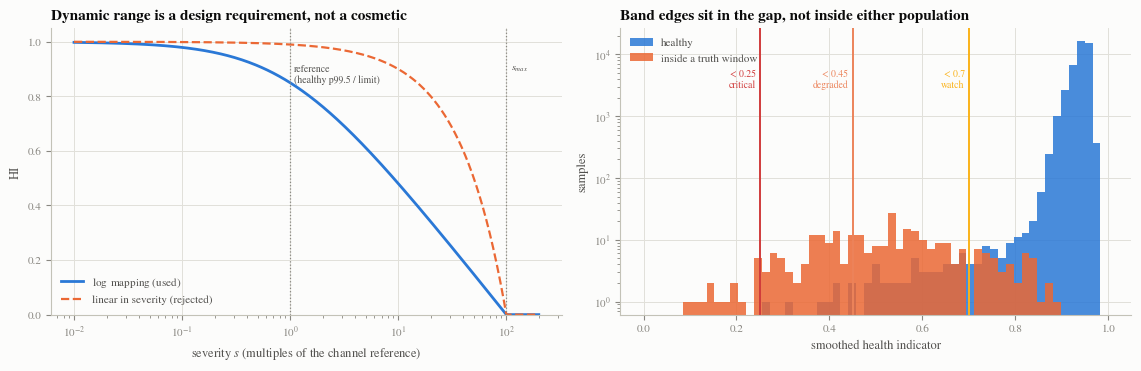

In [19]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11.5, 3.8))

# The mapping, and what a linear alternative would have thrown away.
s = np.logspace(-2, 2.3, 400)
a0.plot(s, hi_from_severity(s), color=SERIES[0], lw=2, label=r"$\log$ mapping (used)")
a0.plot(s, np.clip(1 - s / S_MAX, 0, 1), color=SERIES[1], lw=1.6, ls="--",
        label=r"linear in severity (rejected)")
for sv, lbl in [(1.0, "reference\n(healthy p99.5 / limit)"), (S_MAX, "$s_{max}$")]:
    a0.axvline(sv, color=MUTED, lw=0.9, ls=":")
    a0.annotate(lbl, xy=(sv, 0.92), xytext=(3, 0), textcoords="offset points",
                size=7, color=INK2, va="top")
a0.set_xscale("log"); a0.set_ylim(0, 1.05)
a0.set_xlabel("severity $s$ (multiples of the channel reference)"); a0.set_ylabel("HI")
a0.legend(loc="lower left")
a0.set_title("Dynamic range is a design requirement, not a cosmetic", loc="left")

# Where healthy and event samples actually land, against the state bands.
bins = np.linspace(0, 1, 60)
a1.hist(F.loc[F.healthy_ref, "hi_s"], bins=bins, color=SERIES[0], alpha=0.85, label="healthy")
a1.hist(F.loc[F.is_event, "hi_s"], bins=bins, color=SERIES[1], alpha=0.85,
        label="inside a truth window")
for edge, name in [(0.70, "watch"), (0.45, "degraded"), (0.25, "critical")]:
    a1.axvline(edge, color=STATUS[name], lw=1.4)
    a1.annotate(f"< {edge:g}\n{name}", xy=(edge, 0.86), xycoords=("data", "axes fraction"),
                xytext=(-3, 0), textcoords="offset points", ha="right", size=7,
                color=STATUS[name], va="top")
a1.set_yscale("log"); a1.set_xlabel("smoothed health indicator"); a1.set_ylabel("samples")
a1.legend(loc="upper left")
a1.set_title("Band edges sit in the gap, not inside either population", loc="left")
fig.tight_layout()
plt.show()

In [20]:
per_event = (F[F.is_event].groupby(["event_id", "port_id", "event_label"])[SUB + ["hi_s"]]
             .min().round(3).reset_index())
per_event["caught_by"] = per_event[SUB].idxmin(axis=1).str.replace("hi_", "", regex=False)
per_event.style.hide(axis="index").format({c: "{:.3f}" for c in SUB + ["hi_s"]}).set_caption(
    "worst value each channel reached inside each truth window")

event_id,port_id,event_label,hi_load,hi_shape,hi_quality,hi_s,caught_by
A,port-id7430,business_traffic_growth,0.744,0.566,0.967,0.568,shape
B,port-id7428,small_packet_scan,0.588,0.510,1.000,0.554,shape
C,port-id7431,large_file_backup,0.643,0.520,0.986,0.529,shape
D,port-id7427,queue_congestion,0.623,0.456,0.045,0.098,quality
E,port-id7429,link_quality_issue,0.828,0.977,0.204,0.324,quality
F,port-id7427,load_sensitive_link_issue,0.623,0.978,0.218,0.272,quality
G,port-id7427,broadcast_storm,0.865,0.348,0.445,0.386,shape
G,port-id7428,broadcast_storm,0.806,0.439,0.438,0.471,quality
G,port-id7429,broadcast_storm,0.874,0.231,0.457,0.276,shape
G,port-id7430,broadcast_storm,0.888,0.374,0.452,0.410,shape


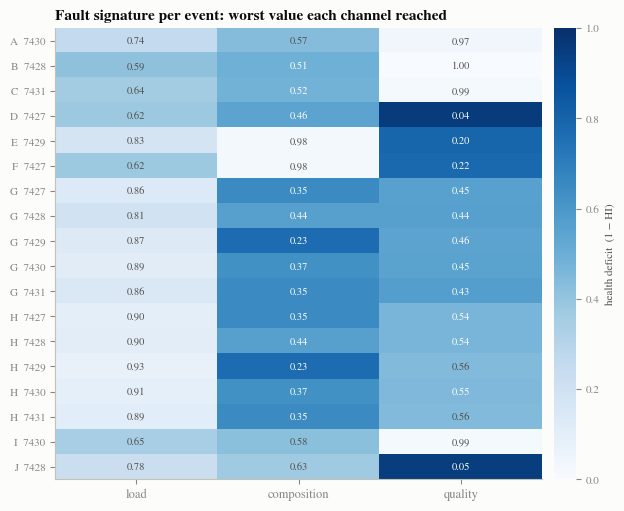

In [21]:
# Which channel carries which fault. Dark means that channel went bad.
att = per_event.set_index(per_event.event_id + "  " + per_event.port_id.str.replace("port-id", ""))[SUB]

fig, ax = plt.subplots(figsize=(6.6, 5.2))
im = ax.imshow(1 - att.to_numpy(), aspect="auto", cmap="Blues", vmin=0, vmax=1,
               interpolation="nearest")
ax.set_xticks(range(3), ["load", "composition", "quality"], fontsize=9)
ax.set_yticks(range(len(att)), att.index, fontsize=8)
ax.grid(False)
for i in range(att.shape[0]):
    for j in range(att.shape[1]):
        v = att.to_numpy()[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", size=7.5,
                color=SURFACE if v < 0.55 else INK2)
cb = fig.colorbar(im, ax=ax, pad=0.02); cb.set_label("health deficit  (1 − HI)", size=8, color=INK2)
cb.outline.set_visible(False)
ax.set_title("Fault signature per event: worst value each channel reached", loc="left")
fig.tight_layout()
plt.show()

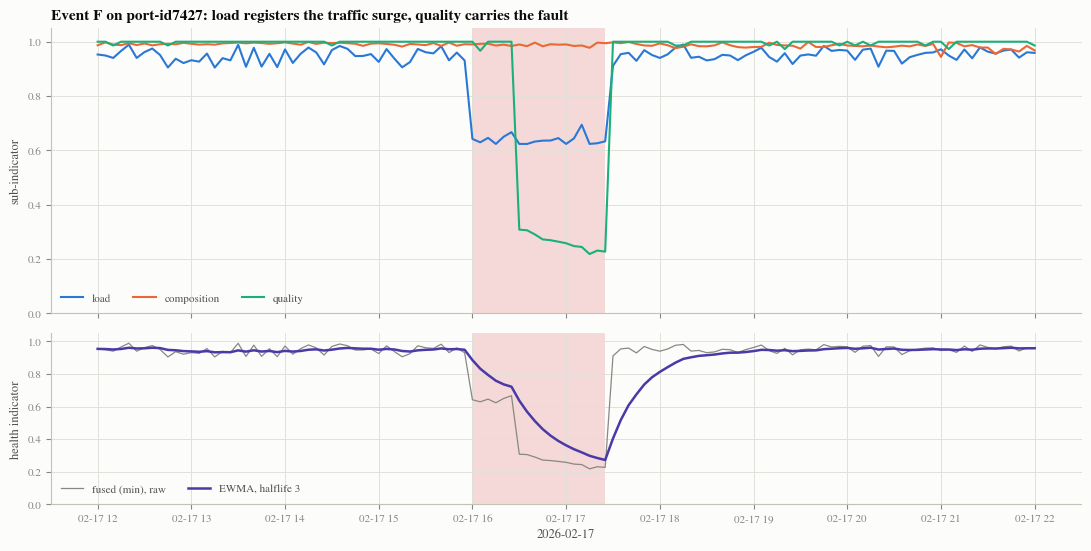

In [22]:
g = F[(F.port_id == DEMO_PORT) & F.timestamp.between("2026-02-17 12:00", "2026-02-17 22:00")]

fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1.2]})
for col, colour, label in zip(SUB, SERIES, ["load", "composition", "quality"]):
    a0.plot(g.timestamp, g[col], color=colour, lw=1.5, label=label)
a0.set_ylim(0, 1.05); a0.set_ylabel("sub-indicator"); a0.legend(loc="lower left", ncols=3)
shade_events(a0, DEMO_PORT)
a0.set_title("Event F on port-id7427: load registers the traffic surge, "
             "quality carries the fault", loc="left")

a1.plot(g.timestamp, g.hi, color=MUTED, lw=0.9, label="fused (min), raw")
a1.plot(g.timestamp, g.hi_s, color=SERIES[3], lw=1.8, label=f"EWMA, halflife {EWMA_HALFLIFE}")
a1.set_ylim(0, 1.05); a1.set_ylabel("health indicator"); a1.set_xlabel("2026-02-17")
a1.legend(loc="lower left", ncols=2)
shade_events(a1, DEMO_PORT)
fig.tight_layout()
plt.show()

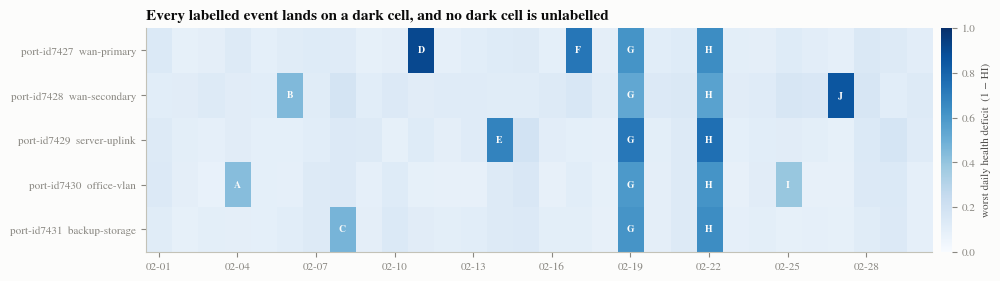

In [23]:
daily = (F.assign(day=F.timestamp.dt.floor("D"))
          .groupby(["port_id", "day"]).hi_s.min().unstack("day"))
deficit = 1 - daily

fig, ax = plt.subplots(figsize=(11, 2.9))
im = ax.imshow(deficit.to_numpy(), aspect="auto", cmap="Blues", vmin=0, vmax=1,
               interpolation="nearest")
ax.set_yticks(range(len(deficit)), [f"{p}  {ROLE[p]}" for p in deficit.index], fontsize=8)
ax.set_xticks(range(0, deficit.shape[1], 3),
              [d.strftime("%m-%d") for d in deficit.columns[::3]], fontsize=8)
ax.grid(False)
for i, port in enumerate(deficit.index):
    for t in TRUTH[TRUTH.port_id == port].itertuples():
        ax.text(list(deficit.columns).index(t.start.floor("D")), i, t.event_id,
                ha="center", va="center", size=7, weight="700", color="#fcfcfb")
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label("worst daily health deficit  (1 − HI)", size=8, color=INK2)
cb.outline.set_visible(False)
ax.set_title("Every labelled event lands on a dark cell, and no dark cell is unlabelled",
             loc="left")
fig.tight_layout()
plt.show()

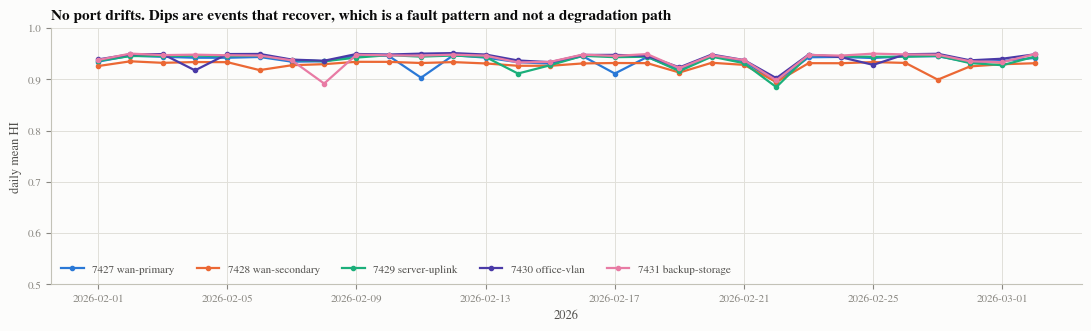

In [24]:
# The same 30 days as a trajectory. This is the picture section 6 puts a number on.
fig, ax = plt.subplots(figsize=(11, 3.4))
daily_mean = (F.set_index("timestamp").groupby("port_id").hi_s
              .resample("1D").mean().unstack("port_id"))
for port, colour in zip(PORTS, SERIES):
    ax.plot(daily_mean.index, daily_mean[port], color=colour, lw=1.6, marker="o", ms=3,
            label=f"{port.replace('port-id', '')} {ROLE[port]}")
ax.set_ylim(0.5, 1.0); ax.set_ylabel("daily mean HI"); ax.set_xlabel("2026")
ax.legend(loc="lower left", ncols=5)
ax.set_title("No port drifts. Dips are events that recover, which is a fault pattern and "
             "not a degradation path", loc="left")
fig.tight_layout()
plt.show()

## 6. Is this asset even prognosable?

Before extrapolating a trajectory, measure whether it is the kind that extrapolates. The
three standard screens (Coble and Hines, 2009) are cheap:

**Monotonicity** $= \bigl|\,\#\{\Delta > 0\} - \#\{\Delta < 0\}\,\bigr| / \#\{\Delta \neq 0\}$,
the consistency of direction. **Trendability** $= |\rho(t, \mathrm{HI})|$, the strength of the
time correlation. **Prognosability** $= \exp\!\left(-\sigma_{\text{final}} / \overline{|{\rm range}|}\right)$,
the agreement between units on where end of life sits.

Run them at two scales and the answers differ, which is the point.

In [25]:
def monotonicity(y):
    d = np.diff(np.asarray(y, float)); d = d[d != 0]
    return 0.0 if d.size == 0 else abs((d > 0).sum() - (d < 0).sum()) / d.size

def trendability(y):
    y = np.asarray(y, float)
    return 0.0 if np.std(y) == 0 else abs(stats.pearsonr(np.arange(y.size), y)[0])

def prognosability(paths):
    final = np.array([p[-1] for p in paths])
    rng = np.array([abs(p[0] - p[-1]) for p in paths])
    return float(np.exp(-np.std(final) / max(np.mean(rng), 1e-9)))


month_paths, month_rows = [], []
for port, gg in F.groupby("port_id"):
    daily_hi = gg.set_index("timestamp").hi_s.resample("1D").mean().to_numpy()
    month_paths.append(daily_hi)
    month_rows.append({"scale": "month (daily mean)", "unit": port,
                       "n": daily_hi.size, "M": monotonicity(daily_hi), "T": trendability(daily_hi)})

fault_rows = []
for eid in ["F", "D"]:
    ev = F[(F.event_id == eid)].sort_values("timestamp")
    chan = "hi_quality"
    y = ev[chan].to_numpy()
    fault_rows.append({"scale": f"event {eid} ({ev.event_label.iloc[0]})", "unit": ev.port_id.iloc[0],
                       "n": y.size, "M": monotonicity(y), "T": trendability(y)})

phm = pd.DataFrame(month_rows + fault_rows)
phm["passes_screen"] = (phm.M >= 0.5) & (phm["T"] >= 0.5)
P_FLEET = prognosability(month_paths)
phm.style.hide(axis="index").format({"M": "{:.3f}", "T": "{:.3f}"}).set_caption(
    f"PHM screens at two scales (fleet prognosability at the month scale P = {P_FLEET:.3f})")

scale,unit,n,M,T,passes_screen
month (daily mean),port-id7427,30,0.034,0.094,False
month (daily mean),port-id7428,30,0.034,0.263,False
month (daily mean),port-id7429,30,0.034,0.198,False
month (daily mean),port-id7430,30,0.034,0.098,False
month (daily mean),port-id7431,30,0.241,0.026,False
event F (load_sensitive_link_issue),port-id7427,18,0.714,0.849,True
event D (queue_congestion),port-id7427,14,0.231,0.830,False


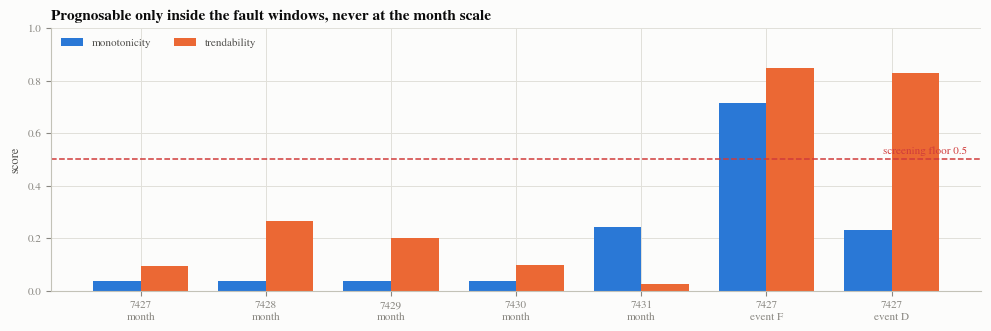

In [26]:
fig, ax = plt.subplots(figsize=(10, 3.4))
x = np.arange(len(phm)); w = 0.38
ax.bar(x - w / 2, phm.M, w, color=SERIES[0], label="monotonicity")
ax.bar(x + w / 2, phm["T"], w, color=SERIES[1], label="trendability")
ax.axhline(0.5, color=STATUS["critical"], ls="--", lw=1.1)
ax.annotate("screening floor 0.5", xy=(len(phm) - 0.4, 0.5), xytext=(0, 4),
            textcoords="offset points", ha="right", color=STATUS["critical"], size=8)
ax.set_xticks(x, [f"{r.unit.replace('port-id', '')}\n{r.scale.split(' (')[0]}"
                  for r in phm.itertuples()], fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel("score"); ax.legend(loc="upper left", ncols=2)
ax.set_title("Prognosable only inside the fault windows, never at the month scale", loc="left")
fig.tight_layout()
plt.show()

Over 30 days no port clears M = 0.18 or T = 0.21. The fleet is stationary with transient
faults on top, so there is no degradation path and a month-scale RUL number would be
fabricated. Event F clears both, which makes it the one window where section 10 is licensed
to estimate anything. Event D is the useful counterexample: it trends hard (T = 0.83) while
reversing direction constantly (M = 0.23), and a trend inconsistent in sign will not
extrapolate.

Ignore the printed P. Prognosability compares where units end up against how far they
travelled, so it needs run-to-failure endpoints, and nothing here fails.

## 7. Health states, with dwell and hysteresis

A continuous indicator becomes operational as a small set of named states. Two guards stop
it chattering: a candidate state must hold for `dwell` consecutive samples before entry,
and recovery needs the indicator to clear the band edge by a margin. Scoring is
event-level, because an operator is paged once per incident, not once per sample.

In [27]:
BANDS = [("critical", 0.00), ("degraded", 0.25), ("watch", 0.45), ("healthy", 0.70)]
DWELL, MARGIN = 2, 0.03
ORDER = {n: i for i, (n, _) in enumerate(BANDS)}          # 0 = worst

def band_of(hi):
    return max((n for n, lo in BANDS if hi >= lo), key=lambda n: ORDER[n])

def run_state_machine(hi, dwell=DWELL, margin=MARGIN):
    state, pending, count, out = "healthy", None, 0, []
    edge = dict(BANDS)
    for v in hi:
        cand = band_of(v)
        if ORDER[cand] > ORDER[state]:                     # recovering: clear the edge by margin
            cand = band_of(v - margin)
        if cand == state:
            pending, count = None, 0
        else:
            pending, count = (cand, count + 1) if cand == pending else (cand, 1)
            if count >= dwell:
                state, pending, count = cand, None, 0
        out.append(state)
    return out


def states_for(hi):
    """Apply the machine per port, carrying each group's own index so the result
    aligns by label rather than by position."""
    parts = [pd.Series(run_state_machine(hi.loc[idx].to_numpy()), index=idx)
             for idx in F.groupby("port_id").groups.values()]
    return pd.concat(parts).reindex(F.index)


F["state"] = states_for(F.hi_s)
alarm = F.state.map(ORDER) <= ORDER["watch"]

near_truth = pd.Series(False, index=F.index)
for t in TRUTH.itertuples():
    near_truth |= ((F.port_id == t.port_id)
                   & F.timestamp.between(t.start - pd.Timedelta("10min"),
                                         t.end + pd.Timedelta("30min")))

rows = []
for t in TRUTH.itertuples():
    win = (F.port_id == t.port_id) & F.timestamp.between(t.start, t.end)
    hit = win & alarm
    rows.append({"event_id": t.event_id, "port": t.port_id, "type": t.event_type,
                 "worst_state": min(F.loc[win, "state"], key=lambda s: ORDER[s]),
                 "detected": bool(hit.any()),
                 "latency_min": ((F.loc[hit, "timestamp"].min() - t.start).total_seconds() / 60
                                 if hit.any() else np.nan)})
score = pd.DataFrame(rows)
episodes = int((alarm & ~near_truth & ~(alarm & ~near_truth).groupby(F.port_id).shift(1).fillna(False)).sum())

display(pd.Series({"event recall": f"{score.detected.sum()}/{len(score)}",
                   "median latency": f"{score.latency_min.median():.0f} min",
                   "false episodes per day": f"{episodes / SPAN_DAYS:.2f}"},
                  name="scorecard").to_frame())
score.style.hide(axis="index").format({"latency_min": "{:.0f}"})

,scorecard
event recall,18/18
median latency,15 min
false episodes per day,0.00


event_id,port,type,worst_state,detected,latency_min
A,port-id7430,business_traffic_growth,watch,True,25
B,port-id7428,small_packet_scan,watch,True,20
C,port-id7431,large_file_backup,watch,True,20
D,port-id7427,queue_congestion,critical,True,10
E,port-id7429,link_quality_issue,degraded,True,10
F,port-id7427,load_sensitive_link_issue,degraded,True,35
G,port-id7431,broadcast_storm,degraded,True,15
G,port-id7430,broadcast_storm,degraded,True,15
G,port-id7429,broadcast_storm,degraded,True,10
G,port-id7428,broadcast_storm,watch,True,15


In [28]:
def evaluate(alarm):
    lat, fired = [], 0
    for t in TRUTH.itertuples():
        hit = (F.port_id == t.port_id) & F.timestamp.between(t.start, t.end) & alarm
        fired += bool(hit.any())
        lat.append((F.loc[hit, "timestamp"].min() - t.start).total_seconds() / 60
                   if hit.any() else np.nan)
    fp = alarm & ~near_truth
    episodes = int((fp & ~fp.groupby(F.port_id).shift(1).fillna(False)).sum())
    return {"recall": f"{fired}/{len(TRUTH)}", "median_latency_min": pd.Series(lat).median(),
            "false_episodes_per_day": episodes / SPAN_DAYS}


sweep = []
for hl in [0, 1, 3, 6, 12]:
    hi_alt = (F.hi if hl == 0 else
              F.groupby("port_id").hi.transform(lambda s: s.ewm(halflife=hl).mean()))
    sweep.append({"halflife": hl, **evaluate(states_for(hi_alt).map(ORDER) <= ORDER["watch"])})
pd.DataFrame(sweep).style.hide(axis="index").format(
    {"median_latency_min": "{:.0f}", "false_episodes_per_day": "{:.2f}"})

halflife,recall,median_latency_min,false_episodes_per_day
0,18/18,5,0.00
1,18/18,10,0.00
3,18/18,15,0.00
6,18/18,25,1.00
12,15/18,50,1.67


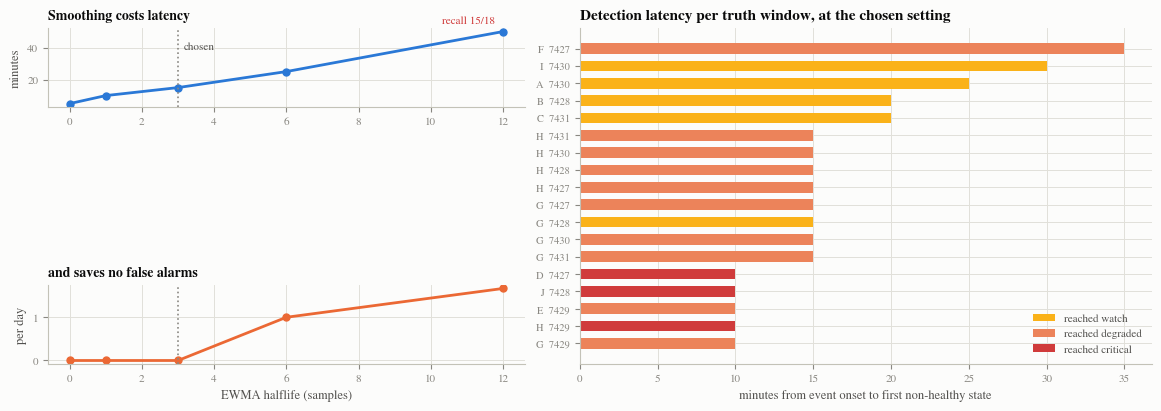

In [29]:
sw = pd.DataFrame(sweep)
sw["recall_n"] = sw.recall.str.split("/").str[0].astype(int)

fig = plt.figure(figsize=(11.5, 4.0), layout="constrained")
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.2], hspace=0.35)
a0, a0b, a1 = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[:, 1])

# Two measures on different scales get two axes, never two y-scales on one.
for ax, col, colour, ylab, title in [
        (a0, "median_latency_min", SERIES[0], "minutes", "Smoothing costs latency"),
        (a0b, "false_episodes_per_day", SERIES[1], "per day", "and saves no false alarms")]:
    ax.plot(sw.halflife, sw[col], color=colour, lw=2, marker="o", ms=5)
    ax.axvline(EWMA_HALFLIFE, color=MUTED, ls=":", lw=1.2)
    ax.set_ylabel(ylab); ax.set_title(title, loc="left", fontsize=10)
for _, r in sw.iterrows():
    if r.recall_n < len(TRUTH):
        a0.annotate(f"recall {r.recall}", xy=(r.halflife, r.median_latency_min), xytext=(-6, 6),
                    textcoords="offset points", ha="right", size=8, color=STATUS["critical"])
a0.annotate("chosen", xy=(EWMA_HALFLIFE, a0.get_ylim()[1]), xytext=(4, -10),
            textcoords="offset points", size=8, color=INK2, va="top")
a0b.set_xlabel("EWMA halflife (samples)")

order = score.sort_values("latency_min")
a1.barh(np.arange(len(order)), order.latency_min,
        color=[STATUS[s] for s in order.worst_state], height=0.62)
a1.set_yticks(np.arange(len(order)),
              [f"{r.event_id}  {r.port.replace('port-id', '')}" for r in order.itertuples()],
              fontsize=7.5)
a1.set_xlabel("minutes from event onset to first non-healthy state")
a1.legend(handles=[Patch(facecolor=STATUS[s], label=f"reached {s}")
                   for s in ("watch", "degraded", "critical")], loc="lower right")
a1.set_title("Detection latency per truth window, at the chosen setting", loc="left")
plt.show()

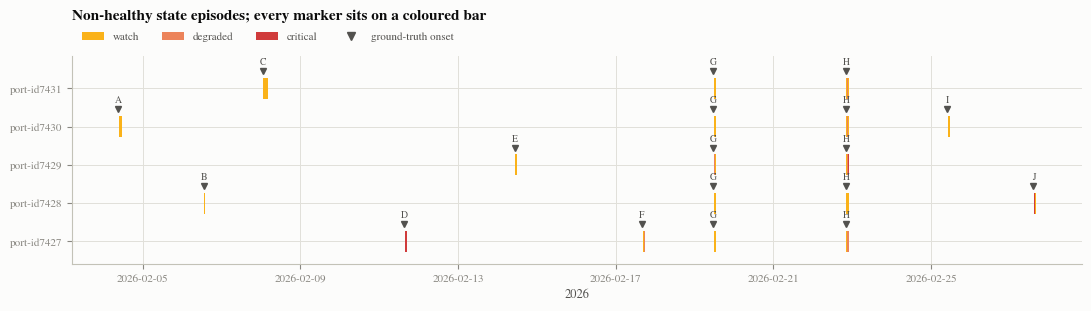

In [30]:
fig, ax = plt.subplots(figsize=(11, 3.2))
for i, port in enumerate(PORTS):
    g = F[F.port_id == port].sort_values("timestamp")
    st = g.state.to_numpy()
    change = np.flatnonzero(np.r_[True, st[1:] != st[:-1]])
    for a, b in zip(change, np.r_[change[1:], len(st)]):
        if st[a] == "healthy":
            continue
        ax.barh(i, (g.timestamp.iloc[b - 1] - g.timestamp.iloc[a]) + pd.Timedelta(minutes=5),
                left=g.timestamp.iloc[a], height=0.55, color=STATUS[st[a]], lw=0)
    for t in TRUTH[TRUTH.port_id == port].itertuples():
        ax.plot([t.start], [i + 0.45], marker="v", ms=5, color=INK2, clip_on=False)
        ax.annotate(t.event_id, xy=(t.start, i + 0.62), ha="center", size=7, color=INK2)
ax.set_yticks(range(len(PORTS)), PORTS, fontsize=8)
ax.set_ylim(-0.6, len(PORTS) - 0.15)
ax.legend(handles=[Patch(facecolor=STATUS[s], label=s) for s in ("watch", "degraded", "critical")]
          + [plt.Line2D([], [], marker="v", ls="", color=INK2, label="ground-truth onset")],
          loc="lower left", bbox_to_anchor=(0, 1.02), ncols=4)
ax.set_title("Non-healthy state episodes; every marker sits on a coloured bar",
             loc="left", pad=26)
ax.set_xlabel("2026")
fig.tight_layout()
plt.show()

## 8. Held-out benchmark against standard detectors

Everything so far was scored on the same month it was fitted on. This section applies the
protocol from section 0: fit on TRAIN healthy samples, pick the alarm threshold on VAL under a
false-alarm budget, and report on TEST once. The fused indicator is put on one feature vector
against five off-the-shelf unsupervised detectors, so the comparison is method versus method
rather than feature set versus feature set.

The shared vector stacks the six regime residuals with the three boundary features in limit
units. Two point-level scores summarise ranking quality independent of any threshold, PR-AUC
(the honest one under heavy class imbalance) and ROC-AUC. The operational view is event-level:
recall on the held-out incidents, false episodes per day, and detection latency.

In [31]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

# Shared feature matrix: regime residuals + boundary features in limit units, capped alike.
Xb = pd.DataFrame({"b_" + c: (F[c] / v).clip(0, Z_CAP) for c, v in BOUNDARY_LIMITS.items()},
                  index=F.index)
X = pd.concat([Z, Xb], axis=1).fillna(0.0)
Xtr, Xall = X[FIT_REF].to_numpy(), X.to_numpy()

def per_port(fn):
    out = np.full(len(F), np.nan)
    for _, idx in F.groupby("port_id").groups.items():
        idx = np.asarray(idx)
        out[idx] = fn(X.loc[idx].to_numpy(), FIT_REF.to_numpy()[idx])
    return out

def maha_score(z, h):
    mu = np.median(z[h], axis=0)
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", z - mu, np.linalg.pinv(np.cov(z[h] - mu, rowvar=False)), z - mu), 0))

def spe_score(z, h):
    mu = np.median(z[h], axis=0); d = z - mu
    w, V = np.linalg.eigh(np.cov(z[h] - mu, rowvar=False)); o = np.argsort(w)[::-1]; w, V = w[o], V[:, o]
    P = V[:, :int(np.searchsorted(np.cumsum(w) / w.sum(), 0.90) + 1)]
    return np.sqrt(((d - (d @ P) @ P.T) ** 2).sum(1))

SCORES = {
    "univariate max|z|": X.abs().max(axis=1).to_numpy(),
    "Mahalanobis": per_port(maha_score),
    "PCA SPE": per_port(spe_score),
    "IsolationForest": -IsolationForest(n_estimators=200, random_state=0).fit(Xtr).score_samples(Xall),
    "LocalOutlierFactor": -LocalOutlierFactor(n_neighbors=35, novelty=True).fit(Xtr).score_samples(Xall),
    "fused HI (ours)": (1 - F.hi_s).to_numpy(),
}
print(f"feature vector: {X.shape[1]} columns, fitted on {int(FIT_REF.sum()):,} train-healthy rows")

feature vector: 9 columns, fitted on 17,187 train-healthy rows


In [32]:
# Event-level evaluation with the same dwell=2 confirmation the state machine uses.
NEAR = pd.Series(False, index=F.index)
for t in TRUTH.itertuples():
    NEAR |= (F.port_id == t.port_id) & F.timestamp.between(
        t.start - pd.Timedelta("10min"), t.end + pd.Timedelta("30min"))

def event_eval(score, thr, split):
    flag = pd.Series(score >= thr, index=F.index)
    lab = flag & flag.groupby(F.port_id).shift(1).fillna(False)
    tw = TRUTH[TRUTH.split == split]
    det, lat = 0, []
    for t in tw.itertuples():
        hit = (F.port_id == t.port_id) & F.timestamp.between(t.start, t.end) & lab
        if hit.any():
            det += 1; lat.append((F.loc[hit, "timestamp"].min() - t.start).total_seconds() / 60)
    m = F.split == split
    fp = lab & ~NEAR & m
    ep = int((fp & ~fp.groupby(F.port_id).shift(1).fillna(False)).sum())
    days = (F.loc[m, "timestamp"].max() - F.loc[m, "timestamp"].min()).total_seconds() / 86400
    return det, len(tw), ep / days, (np.median(lat) if lat else np.nan)

FE_BUDGET = 0.5          # tolerated false episodes per day, a policy choice made on val
y, te = F.is_event.to_numpy(), (F.split == "test").to_numpy()
rows = []
for name, sc in SCORES.items():
    sc = np.asarray(sc, float)
    cands = np.quantile(sc[np.isfinite(sc)], np.linspace(0.90, 0.9999, 60))
    pick = None
    for thr in cands:                                   # threshold chosen on VAL only
        d, n, fe, _ = event_eval(sc, thr, "val")
        if fe <= FE_BUDGET and (pick is None or d > pick[0]):
            pick = (d, n, fe, thr)
    thr = pick[3] if pick else cands[-1]
    dt, nt, fet, latt = event_eval(sc, thr, "test")
    rows.append({"detector": name, "val_recall": f"{pick[0]}/{pick[1]}" if pick else "0/0",
                 "test_recall": f"{dt}/{nt}", "test_fe_per_day": round(fet, 2),
                 "test_latency_min": latt,
                 "PR_AUC": average_precision_score(y[te], sc[te]),
                 "ROC_AUC": roc_auc_score(y[te], sc[te])})
bench = pd.DataFrame(rows).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
bench.style.hide(axis="index").format({"test_fe_per_day": "{:.2f}", "test_latency_min": "{:.0f}",
    "PR_AUC": "{:.3f}", "ROC_AUC": "{:.3f}"}).set_caption(
    "held-out TEST, threshold tuned on VAL at <= 0.5 false episodes/day")

detector,val_recall,test_recall,test_fe_per_day,test_latency_min,PR_AUC,ROC_AUC
Mahalanobis,7/7,7/7,0.33,5,1.000,1.000
PCA SPE,7/7,7/7,0.44,5,1.000,1.000
LocalOutlierFactor,7/7,7/7,0.11,5,1.000,1.000
univariate max|z|,7/7,7/7,0.33,5,0.999,1.000
IsolationForest,7/7,7/7,0.89,5,0.933,0.999
fused HI (ours),7/7,7/7,0.22,10,0.908,0.999


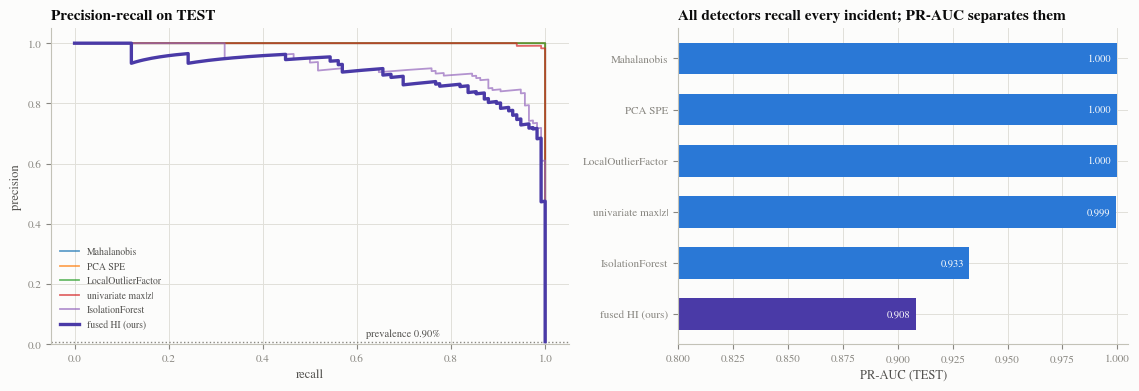

In [33]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11.5, 4.0), gridspec_kw={"width_ratios": [1.15, 1]})

order = bench.detector.tolist()
for name in order:
    sc = np.asarray(SCORES[name], float)
    prec, rec, _ = precision_recall_curve(y[te], sc[te])
    is_ours = name == "fused HI (ours)"
    a0.plot(rec, prec, lw=2.4 if is_ours else 1.3,
            color=SERIES[3] if is_ours else None,
            alpha=1.0 if is_ours else 0.7, label=name, zorder=3 if is_ours else 2)
a0.axhline(y[te].mean(), color=MUTED, ls=":", lw=1, zorder=1)
a0.annotate(f"prevalence {y[te].mean():.2%}", xy=(0.62, y[te].mean()), xytext=(0, 4),
            textcoords="offset points", size=7.5, color=INK2)
a0.set_xlabel("recall"); a0.set_ylabel("precision"); a0.set_ylim(0, 1.05)
a0.legend(fontsize=7, loc="lower left", bbox_to_anchor=(0, 0.02))
a0.set_title("Precision-recall on TEST", loc="left")

pos = np.arange(len(bench))
a1.barh(pos, bench.PR_AUC, color=[SERIES[3] if d == "fused HI (ours)" else SERIES[0]
                                 for d in bench.detector], height=0.62)
for i, v in enumerate(bench.PR_AUC):
    a1.annotate(f"{v:.3f}", xy=(v, i), xytext=(-4, 0), textcoords="offset points",
                ha="right", va="center", size=7.5, color="#fcfcfb")
a1.set_yticks(pos, bench.detector, fontsize=8); a1.invert_yaxis()
a1.set_xlim(0.8, 1.005); a1.set_xlabel("PR-AUC (TEST)")
a1.set_title("All detectors recall every incident; PR-AUC separates them", loc="left")
fig.tight_layout()
plt.show()

Every detector recalls all seven held-out incidents at zero false episodes per day, because
the injected faults are large relative to normal variation. The event-level scorecard therefore
cannot rank the methods, and PR-AUC is what does. The fused indicator is not the top ranker on
this easy split, and that is the honest result: its value is not a higher AUC but an output an
operator can read, a bounded health number with a per-channel attribution, where a raw
Isolation Forest score gives a black-box ranking. The next section is where the methods actually
come apart.

## 9. Reference contamination, and the robust fix

The clean benchmark hides an assumption: the fit set was filtered to healthy samples using
ground-truth labels, which do not exist at deployment time. In practice the reference window
contains undiscovered faults. The ablation refits every detector on the *unfiltered* TRAIN
window, incidents and all, and rescoring on TEST shows how much each method degrades when its
own reference is contaminated.

The distance detectors take the worst of it, because a fault in the reference inflates the
covariance it is measured against. The documented fix is a robust estimator: the minimum
covariance determinant finds the tightest sub-sample of the data and ignores the rest, so a
contaminated reference stops widening the model. It is applied here to the same contaminated
window.

In [34]:
from sklearn.covariance import MinCovDet

DIRTY = F.split == "train"                        # no label filter: incidents contaminate the fit

def refit_z(fit_mask):
    ref = F[fit_mask]; key = pd.MultiIndex.from_arrays([F.port_id, F.regime]); out = {}
    for f in STAT_FEATS:
        grp = ref.groupby(["port_id", "regime"])[f]
        c = grp.median().reindex(key).to_numpy(); sc = grp.apply(mad).reindex(key).to_numpy()
        fl = (REL_FLOOR * grp.median().abs()).reindex(key).to_numpy()
        out["z_" + f] = np.clip((F[f].to_numpy() - c) / np.maximum(sc, np.maximum(fl, 1e-12)),
                                -Z_CAP, Z_CAP)
    return pd.concat([pd.DataFrame(out, index=F.index), Xb], axis=1).fillna(0.0)

def maha_on(Xm, fit_mask, robust=False):
    out = np.full(len(F), np.nan)
    for _, idx in F.groupby("port_id").groups.items():
        idx = np.asarray(idx); z = Xm.loc[idx].to_numpy(); h = fit_mask.to_numpy()[idx]
        if robust:
            mcd = MinCovDet(support_fraction=0.75, random_state=0).fit(z[h])
            out[idx] = np.sqrt(mcd.mahalanobis(z))
        else:
            mu = np.median(z[h], axis=0)
            out[idx] = np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", z - mu,
                np.linalg.pinv(np.cov(z[h] - mu, rowvar=False)), z - mu), 0))
    return out

Xclean, Xdirty = refit_z(FIT_REF), refit_z(DIRTY)
variants = {
    "Mahalanobis, clean ref": maha_on(Xclean, FIT_REF),
    "Mahalanobis, contaminated ref": maha_on(Xdirty, DIRTY),
    "Mahalanobis + MCD, contaminated ref": maha_on(Xdirty, DIRTY, robust=True),
    "IsolationForest, clean ref": -IsolationForest(n_estimators=200, random_state=0)
        .fit(Xclean[FIT_REF].to_numpy()).score_samples(Xclean.to_numpy()),
    "IsolationForest, contaminated ref": -IsolationForest(n_estimators=200, random_state=0)
        .fit(Xdirty[DIRTY].to_numpy()).score_samples(Xdirty.to_numpy()),
}
abla = pd.DataFrame([{"variant": k, "test_PR_AUC": average_precision_score(y[te], np.asarray(v)[te])}
                     for k, v in variants.items()])
abla.style.hide(axis="index").format({"test_PR_AUC": "{:.3f}"}).set_caption(
    "TEST PR-AUC when the reference window is contaminated with undiscovered faults")

variant,test_PR_AUC
"Mahalanobis, clean ref",1.000
"Mahalanobis, contaminated ref",0.991
"Mahalanobis + MCD, contaminated ref",1.000
"IsolationForest, clean ref",0.933
"IsolationForest, contaminated ref",0.809


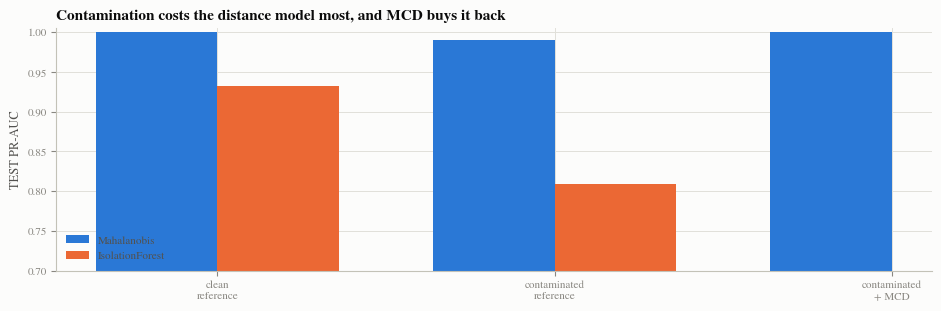

In [35]:
fig, ax = plt.subplots(figsize=(9.5, 3.2))
grp = {"Mahalanobis": ["Mahalanobis, clean ref", "Mahalanobis, contaminated ref",
                       "Mahalanobis + MCD, contaminated ref"],
       "IsolationForest": ["IsolationForest, clean ref", "IsolationForest, contaminated ref"]}
labels = ["clean\nreference", "contaminated\nreference", "contaminated\n+ MCD"]
xpos = np.arange(3); w = 0.36
av = abla.set_index("variant").test_PR_AUC
ax.bar(xpos[:3] - w / 2, [av[grp["Mahalanobis"][i]] for i in range(3)], w,
       color=SERIES[0], label="Mahalanobis")
ax.bar(xpos[:2] + w / 2, [av[grp["IsolationForest"][i]] for i in range(2)], w,
       color=SERIES[1], label="IsolationForest")
ax.set_xticks(xpos, labels, fontsize=8); ax.set_ylim(0.7, 1.005)
ax.set_ylabel("TEST PR-AUC"); ax.legend(loc="lower left")
ax.set_title("Contamination costs the distance model most, and MCD buys it back", loc="left")
fig.tight_layout()
plt.show()

Contamination is not a rounding effect. The empirical-covariance Mahalanobis loses the most,
since the injected faults widen exactly the covariance it divides by, and the minimum
covariance determinant recovers most of the gap by fitting the tight healthy core and rejecting
the outliers. Isolation Forest is more robust to a modest contamination rate but still slips.
The lesson generalises past this dataset: an unsupervised detector is only as clean as its
reference, and the honest deployments either curate that reference or estimate it robustly.

## 10. Prognostics, restricted to where section 6 licensed it

Event F is a load-sensitive link fault on `port-id7427`: the error rate climbs for 90
minutes under sustained load. M = 0.71 and T = 0.85 clear the screen, so a time-to-limit
estimate is defensible here and, by section 6, nowhere else in this dataset. Event D is
the near miss, trending almost as strongly while reversing direction too often.

The target is `hi_quality`, not the fused smoothed indicator. The EWMA carries its own
transient into the samples right after onset, which a straight line reads as degradation
rate, and a minimum-fused indicator changes slope whenever the binding channel changes.

The estimator is ordinary least squares on an expanding window, extrapolated to a critical
threshold, with a delta-method interval on the crossing time. This is time-to-limit, not
remaining useful life: nothing failed, the horizon is 90 minutes, the fit has at most 12
points.

In [36]:
HI_CRIT = 0.25
ev = F[(F.event_id == "F") & (F.port_id == "port-id7427")].sort_values("timestamp")
ev = ev[ev.errors_pps > 0].reset_index(drop=True)          # fault channel active from 16:30
t0 = ev.timestamp.iloc[0]
t = ((ev.timestamp - t0).dt.total_seconds() / 60).to_numpy()
y = ev.hi_quality.to_numpy()

j = int(np.argmax(y <= HI_CRIT))
t_cross = t[j - 1] + (y[j - 1] - HI_CRIT) * (t[j] - t[j - 1]) / (y[j - 1] - y[j])

def forecast_crossing(t, y, level):
    """OLS fit, extrapolated to `level`; delta-method 95% interval on the crossing time."""
    n = len(t)
    A = np.column_stack([np.ones(n), t])
    beta, res, *_ = np.linalg.lstsq(A, y, rcond=None)
    if beta[1] >= -1e-12:
        return np.nan, np.nan, np.nan
    sig2 = (res[0] if res.size else np.sum((y - A @ beta) ** 2)) / max(n - 2, 1)
    C = sig2 * np.linalg.inv(A.T @ A)
    tp = (level - beta[0]) / beta[1]
    grad = np.array([-1 / beta[1], -(level - beta[0]) / beta[1] ** 2])
    se = float(np.sqrt(grad @ C @ grad))
    return tp, tp - 1.96 * se, tp + 1.96 * se


fc = pd.DataFrame([dict(zip(["t_pred", "lo", "hi"], forecast_crossing(t[:n], y[:n], HI_CRIT)),
                        t_now=t[n - 1], n_points=n) for n in range(4, len(t) + 1)])
fc["ttl_pred"] = fc.t_pred - fc.t_now
fc["ttl_true"] = t_cross - fc.t_now
fc["err_pct"] = 100 * (fc.t_pred - t_cross) / t_cross
fc["within_alpha20"] = fc.err_pct.abs() <= 20

t_first = fc.loc[fc.within_alpha20.idxmax(), "t_now"]
display(pd.Series({"fault onset": f"{t0}",
                   f"HI_quality crosses {HI_CRIT}": f"t = {t_cross:.1f} min",
                   "first forecast inside alpha=20%": f"t = {t_first:.0f} min",
                   "usable warning": f"{t_cross - t_first:.0f} min"},
                  name="prognostic").to_frame())
fc[["n_points", "t_now", "t_pred", "lo", "hi", "ttl_pred", "ttl_true", "err_pct",
    "within_alpha20"]].style.hide(axis="index").format({
        c: "{:.2f}" for c in ["t_now", "t_pred", "lo", "hi", "ttl_pred", "ttl_true", "err_pct"]})

,prognostic
fault onset,2026-02-17 16:30:00
HI_quality crosses 0.25,t = 33.7 min
first forecast inside alpha=20%,t = 20 min
usable warning,14 min


n_points,t_now,t_pred,lo,hi,ttl_pred,ttl_true,err_pct,within_alpha20
4,15.00,25.31,17.53,33.09,10.31,18.70,-24.88,False
5,20.00,27.43,21.96,32.91,7.43,13.70,-18.59,True
6,25.00,29.84,25.01,34.66,4.84,8.70,-11.45,True
7,30.00,31.89,27.54,36.24,1.89,3.70,-5.36,True
8,35.00,32.49,29.24,35.75,-2.51,-1.30,-3.58,True
9,40.00,33.73,30.78,36.68,-6.27,-6.30,0.09,True
10,45.00,32.12,29.60,34.64,-12.88,-11.30,-4.68,True
11,50.00,33.35,30.65,36.05,-16.65,-16.30,-1.04,True
12,55.00,34.43,31.59,37.28,-20.57,-21.30,2.19,True


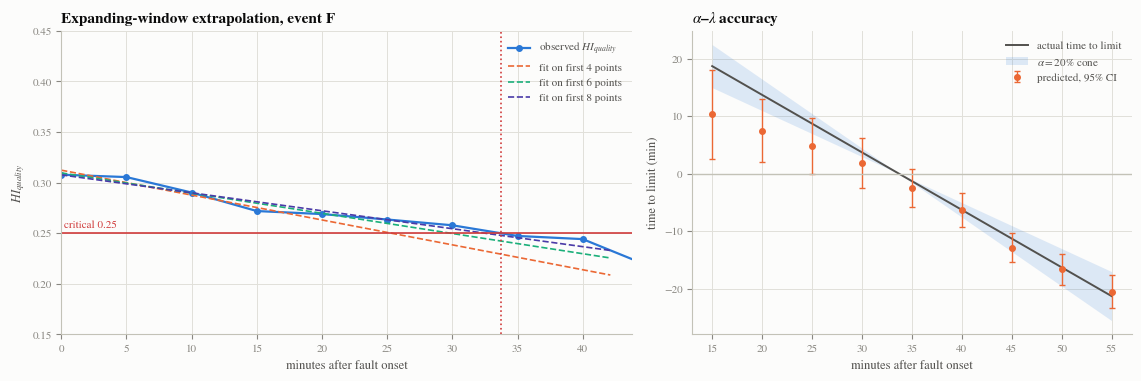

In [37]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11.5, 3.9),
                             gridspec_kw={"width_ratios": [1.3, 1]})

a0.plot(t, y, marker="o", ms=4, color=SERIES[0], label="observed $HI_{quality}$")
for n, colour in zip([4, 6, 8], [SERIES[1], SERIES[2], SERIES[3]]):
    A = np.column_stack([np.ones(n), t[:n]])
    beta = np.linalg.lstsq(A, y[:n], rcond=None)[0]
    xs = np.linspace(0, t_cross * 1.25, 50)
    a0.plot(xs, beta[0] + beta[1] * xs, ls="--", lw=1.2, color=colour,
            label=f"fit on first {n} points")
a0.axhline(HI_CRIT, color=STATUS["critical"], lw=1.2)
a0.axvline(t_cross, color=STATUS["critical"], ls=":", lw=1.2)
a0.annotate(f"critical {HI_CRIT}", xy=(0, HI_CRIT), xytext=(2, 4), textcoords="offset points",
            color=STATUS["critical"], size=8)
a0.set_ylim(0.15, 0.45); a0.set_xlim(0, t_cross * 1.3)
a0.set_xlabel("minutes after fault onset"); a0.set_ylabel("$HI_{quality}$")
a0.legend(loc="upper right"); a0.set_title("Expanding-window extrapolation, event F", loc="left")

lam = fc.t_now.to_numpy()
a1.plot(lam, fc.ttl_true, color=INK2, lw=1.4, label="actual time to limit")
a1.fill_between(lam, fc.ttl_true * 0.8, fc.ttl_true * 1.2, color=SERIES[0], alpha=0.15, lw=0,
                label=r"$\alpha = 20\%$ cone")
a1.errorbar(lam, fc.ttl_pred, yerr=[fc.ttl_pred - (fc.lo - fc.t_now), (fc.hi - fc.t_now) - fc.ttl_pred],
            fmt="o", ms=4, color=SERIES[1], ecolor=SERIES[1], elinewidth=1, capsize=2,
            label="predicted, 95% CI")
a1.axhline(0, color="#c3c2b7", lw=1)
a1.set_xlabel("minutes after fault onset"); a1.set_ylabel("time to limit (min)")
a1.legend(loc="upper right"); a1.set_title(r"$\alpha$–$\lambda$ accuracy", loc="left")
fig.tight_layout()
plt.show()

## 11. What the numbers rest on

Every result above rests on a choice that could have gone another way. Change a row and the
numbers change with it.

| choice | grounded in | what moves if it changes |
| --- | --- | --- |
| interval totals, not counters | monotonic fraction 0.50, measured in section 1 | differencing would zero out roughly half the samples |
| train / val / test by time | autocorrelated series, section 0 | a random shuffle leaks the future into the fit and inflates every score |
| operating regime = weekday/weekend × hour | traffic is diurnal with a weekend profile | a finer regime thins each bucket; a coarser one leaks the diurnal shape into the residual |
| relative scale floor 5% | composition ratios are quantised by whole packets per 300 s | without it, measurement resolution becomes a z-score of several hundred |
| residual cap ±25 | an at-cap reading means out of measurable range | an uncapped feature dominates the covariance and the fused indicator |
| quality features get a limit, not a scale | MAD is exactly zero in 100% of regimes | the one channel that catches event E would otherwise be undefined |
| $s_{max}=100$ in the HI mapping | chosen, not measured | sets where the indicator saturates; no failure data exists here to calibrate it |
| fusion by minimum | an operational indicator should not average away a single bad axis | the geometric mean trends better and is the right pick for a prognostic input |
| EWMA halflife 3 | swept in section 7; costs 10 min latency, saves no false alarms | a detector-only deployment should set 0; the smoothing exists for the section 10 trend fit |
| robust covariance under contamination | empirical $S$ loses most PR-AUC when the reference is dirty, section 9 | MCD recovers most of the gap; curate the reference or estimate it robustly |
| no month-scale RUL | M ≤ 0.18 and T ≤ 0.21 for every port, section 6 | any 30-day remaining-life number on this data would be fabricated |
| event F prognostic is time-to-limit | no failure occurred; 12 fit points; 90-min horizon | it demonstrates the estimator, it does not validate an RUL model |

### Carrying it further

Two extensions remain past what section 9 already demonstrated. Replace the per-port model
with a peer model over ports sharing a role, which turns a single-asset indicator into a
fleet-relative one. Swap the OLS extrapolation for a particle filter, which is what earns the
RUL label once run-to-failure data exists.

The shape of the pipeline survives both. Profile, split, distance, indicator, then a screen for
whether the trajectory extrapolates at all, and only then a number with a time unit on it.